# Classificação de Superfícies de Vias — Voxar Labs PS 2026

**Autor:** Alisson da Silva Bernadino  
**Data:** Abril de 2026  

---

## Identificação da Abordagem

Este notebook resolve o desafio de classificação de imagens em 3 classes (**Asphalt**, **Belgian Blocks**, **Off-road**) utilizando **Transfer Learning** com PyTorch.

**Modelo escolhido:** ResNet-18 pré-treinado no ImageNet  
**Justificativa:** Dado o tempo sugerido de 6–10h, treinar um modelo do zero seria inviável. A ResNet-18 é uma arquitetura pequena (~11M parâmetros), amplamente validada para tarefas de classificação visual. O fine-tuning das camadas superiores adapta os filtros genéricos do ImageNet para as texturas específicas de superfícies de estrada — exatamente o que preciso.

**Bibliotecas principais:**
- `torch` / `torchvision` — backbone, training loop, transforms
- `matplotlib` / `seaborn` — visualizações e matriz de confusão
- `scikit-learn` — métricas (F1, classification report)
- `numpy` / `PIL` — manipulação de arrays e imagens

**Estrutura do notebook:**
1. Entendimento do Problema (EDA)
2. Solução Baseline
3. Experimentos
4. Resultados Consolidados
5. Análise Crítica
6. Uso de Ferramentas

---
## Seção 1 — Entendimento do Problema (EDA & Estratégia)

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from pathlib import Path
import sys
import torch
from IPython.display import display
from collections import defaultdict

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Detecta automaticamente se está no Colab ou local
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/dataset_processed')
else:
    BASE_DIR = Path('dataset_processed')
SPLITS   = ['train', 'test']
CLASSES  = ['asphalt', 'belgian_blocks', 'offroad']
CLASS_LABELS = {'asphalt': 'Asphalt', 'belgian_blocks': 'Belgian Blocks', 'offroad': 'Off-road'}
PALETTE = ["#4A90D9", "#E67E22", "#27AE60"]

print('Dataset path:', BASE_DIR.resolve())
print('Exists:', BASE_DIR.exists())

Mounted at /content/drive
Dataset path: /content/drive/MyDrive/Colab Notebooks/dataset_processed
Exists: True


### 1.1 Natureza do Problema

Trata-se de um problema de **classificação de imagens multiclasse** (3 classes) com características que elevam sua complexidade:

| Desafio | Descrição |
|---|---|
| **Desbalanceamento severo** | A classe *Asphalt* domina o dataset; *Belgian Blocks* é a menor |
| **Variação visual intra-classe** | Iluminação noturna, chuva, sujeira, diferentes câmeras |
| **Similaridade inter-classes** | Off-road e Belgian Blocks podem ter texturas próximas |
| **Ruído de captura** | Diferentes ângulos, resoluções e artefatos de compressão |

In [2]:
# ── 1.2 Distribuição das Classes ──────────────────────────────────────────────
import pandas as pd

counts = {}
for split in SPLITS:
    counts[split] = {}
    for cls in CLASSES:
        path = BASE_DIR / split / cls
        counts[split][cls] = len(list(path.glob('*')))

total_train = sum(counts['train'].values())
total_test  = sum(counts['test'].values())

# ── DataFrame estilizado ──────────────────────────────────────────────────────
_rows = []
for cls in CLASSES:
    tr = counts['train'][cls]
    te = counts['test'][cls]
    _rows.append({'Classe': CLASS_LABELS[cls],
                  'Train': tr, '% Train': tr / total_train,
                  'Test':  te, '% Test':  te / total_test})
_rows.append({'Classe': 'TOTAL',
              'Train': total_train, '% Train': 1.0,
              'Test':  total_test,  '% Test':  1.0})
df_dist = pd.DataFrame(_rows).set_index('Classe')

max_cls = max(counts['train'], key=counts['train'].get)
min_cls = min(counts['train'], key=counts['train'].get)
ratio   = counts['train'][max_cls] / counts['train'][min_cls]

_TS = [
    {'selector': 'caption',
     'props': [('font-size','13px'),('font-weight','bold'),
               ('text-align','left'),('padding-bottom','6px'),('color','#2c3e50')]},
    {'selector': 'thead th',
     'props': [('background-color','#1a1a2e'),('color','white'),
               ('text-align','center'),('padding','8px 14px'),('font-size','12px')]},
    {'selector': 'tbody td',
     'props': [('text-align','center'),('padding','7px 14px'),('font-size','12px')]},
    {'selector': 'tbody th',
     'props': [('text-align','left'),('padding','7px 14px'),('font-weight','normal')]},
    {'selector': 'tbody tr:hover td, tbody tr:hover th',
     'props': [('background-color','#eaf4ff')]},
]

def _style_total(row):
    if row.name == 'TOTAL':
        return ['background-color:#2c3e50;color:white;font-weight:bold'] * len(row)
    return [''] * len(row)

display(
    df_dist.style
    .format({'Train': '{:,}', 'Test': '{:,}',
             '% Train': '{:.1%}', '% Test': '{:.1%}'})
    .apply(_style_total, axis=1)
    .background_gradient(cmap='Blues', subset=['Train', 'Test'], vmin=0)
    .set_caption(
        f'📊 Distribuição do Dataset '
        f'— Razão de desbalanceamento: {ratio:.1f}x '
        f'({CLASS_LABELS[max_cls]} / {CLASS_LABELS[min_cls]})'
    )
    .set_table_styles(_TS)
)


=== Distribuição do Dataset ===

Classe                  Train   %Train     Test    %Test
-------------------------------------------------------
Asphalt                   655    72.8%      218    72.7%
Belgian Blocks             94    10.4%       32    10.7%
Off-road                  151    16.8%       50    16.7%
-------------------------------------------------------
TOTAL                     900   100.0%      300   100.0%

Razão de desbalanceamento (train): 7.0x (Asphalt / Belgian Blocks)


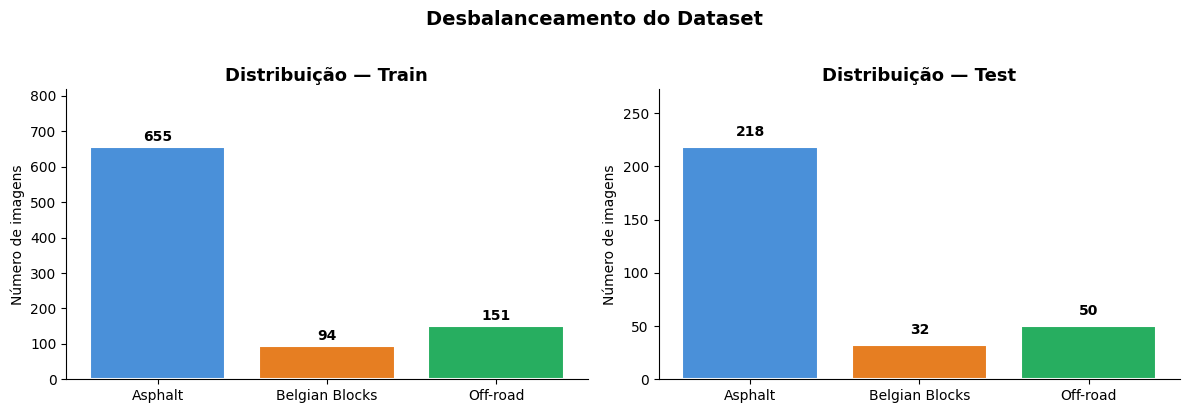

In [3]:
# ── Gráfico de distribuição ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = [CLASS_LABELS[c] for c in CLASSES]

for ax, split in zip(axes, SPLITS):
    vals = [counts[split][c] for c in CLASSES]
    bars = ax.bar(labels, vals, color=PALETTE, edgecolor='white', linewidth=1.5)
    ax.set_title(f'Distribuição — {split.capitalize()}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Número de imagens')
    ax.set_ylim(0, max(vals) * 1.25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                str(v), ha='center', va='bottom', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Desbalanceamento do Dataset', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

**Observação:** O dataset apresenta desbalanceamento severo (~7x entre Asphalt e Belgian Blocks no treino). Isso significa que um modelo ingênuo pode atingir **~73% de acurácia simplesmente prevendo sempre Asphalt** — motivo pelo qual usarei **F1-Score macro** e **Matriz de Confusão por classe** como métricas primárias.

### 1.3 Definição das Métricas de Sucesso

| Métrica | Por quê usar |
|---|---|
| **Acurácia** | Referência geral, mas enganosa com classes desbalanceadas |
| **F1-Score macro** | Métrica primária: trata todas as classes com igual peso |
| **Precision / Recall por classe** | Identifica onde o modelo falha especificamente |
| **Matriz de Confusão** | Evidência visual dos padrões de erro |

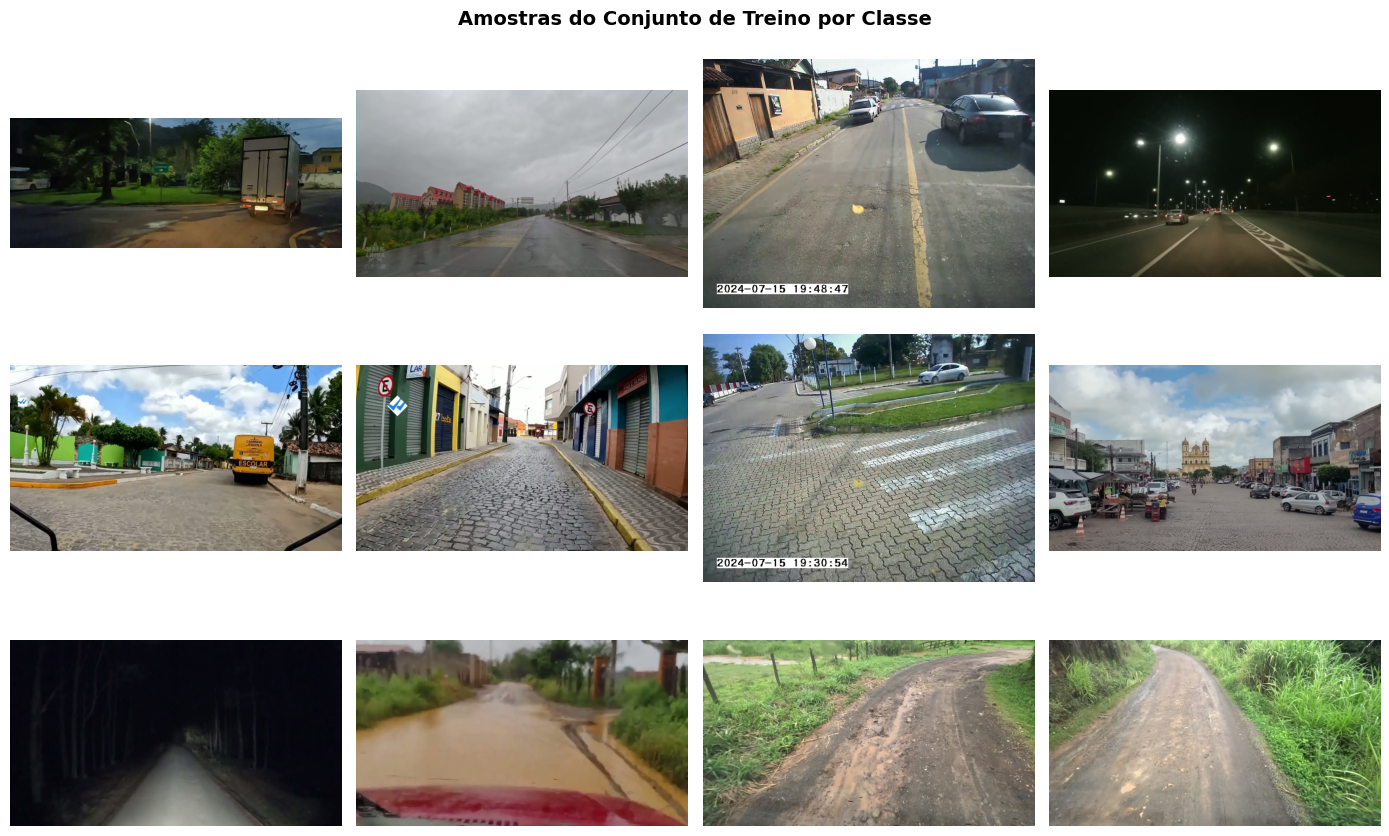

In [4]:
# ── 1.4 Visualização de Amostras por Classe ───────────────────────────────────
def load_random_samples(split, cls, n=4, seed=SEED):
    path = BASE_DIR / split / cls
    files = list(path.glob('*'))
    random.seed(seed)
    chosen = random.sample(files, min(n, len(files)))
    return [Image.open(f).convert('RGB') for f in chosen]

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle('Amostras do Conjunto de Treino por Classe', fontsize=14, fontweight='bold')

for row, cls in enumerate(CLASSES):
    imgs = load_random_samples('train', cls, n=4)
    for col, img in enumerate(imgs):
        ax = axes[row][col]
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(CLASS_LABELS[cls], fontsize=11, fontweight='bold',
                          rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.savefig('eda_class_samples.png', dpi=120, bbox_inches='tight')
plt.show()

=== Análise de Brilho por Classe (treino) ===
  Asphalt           : mean=81.9, min=16.0, max=161.3
  Belgian Blocks    : mean=125.1, min=70.8, max=155.7
  Off-road          : mean=66.8, min=22.1, max=150.4


/tmp/ipykernel_1883/1138835324.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(all_brightness, labels=all_labels, patch_artist=True,


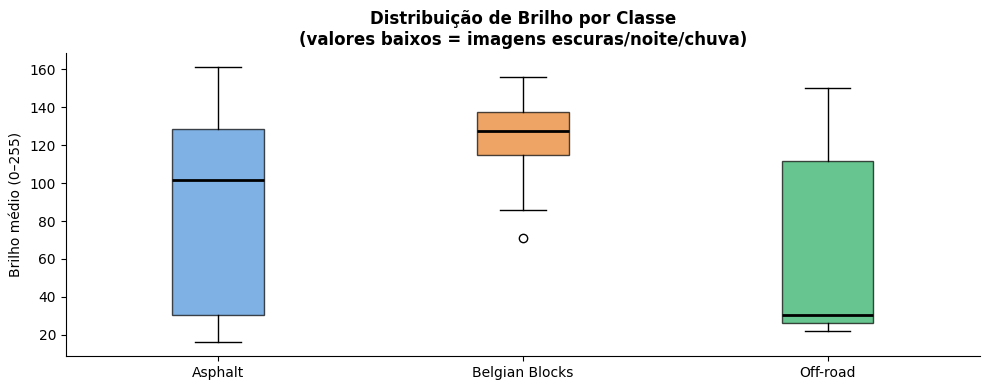

In [5]:
# ── 1.5 Casos Difíceis — Análise Qualitativa ─────────────────────────────────
# Busca imagens escuras (brilho médio baixo) como proxy para "noite/chuva"
def get_image_stats(split, cls, n_sample=30):
    path = BASE_DIR / split / cls
    files = list(path.glob('*'))
    random.seed(SEED)
    sample = random.sample(files, min(n_sample, len(files)))
    stats = []
    for f in sample:
        img = np.array(Image.open(f).convert('RGB'))
        stats.append({'file': f, 'brightness': img.mean(), 'std': img.std()})
    return stats

print('=== Análise de Brilho por Classe (treino) ===')
fig, ax = plt.subplots(figsize=(10, 4))
all_brightness = []
all_labels = []

for cls in CLASSES:
    stats = get_image_stats('train', cls, n_sample=60)
    brightness = [s['brightness'] for s in stats]
    all_brightness.append(brightness)
    all_labels.append(CLASS_LABELS[cls])
    print(f"  {CLASS_LABELS[cls]:<18}: mean={np.mean(brightness):.1f}, min={np.min(brightness):.1f}, max={np.max(brightness):.1f}")

bp = ax.boxplot(all_brightness, labels=all_labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribuição de Brilho por Classe\n(valores baixos = imagens escuras/noite/chuva)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Brilho médio (0–255)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('eda_brightness_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

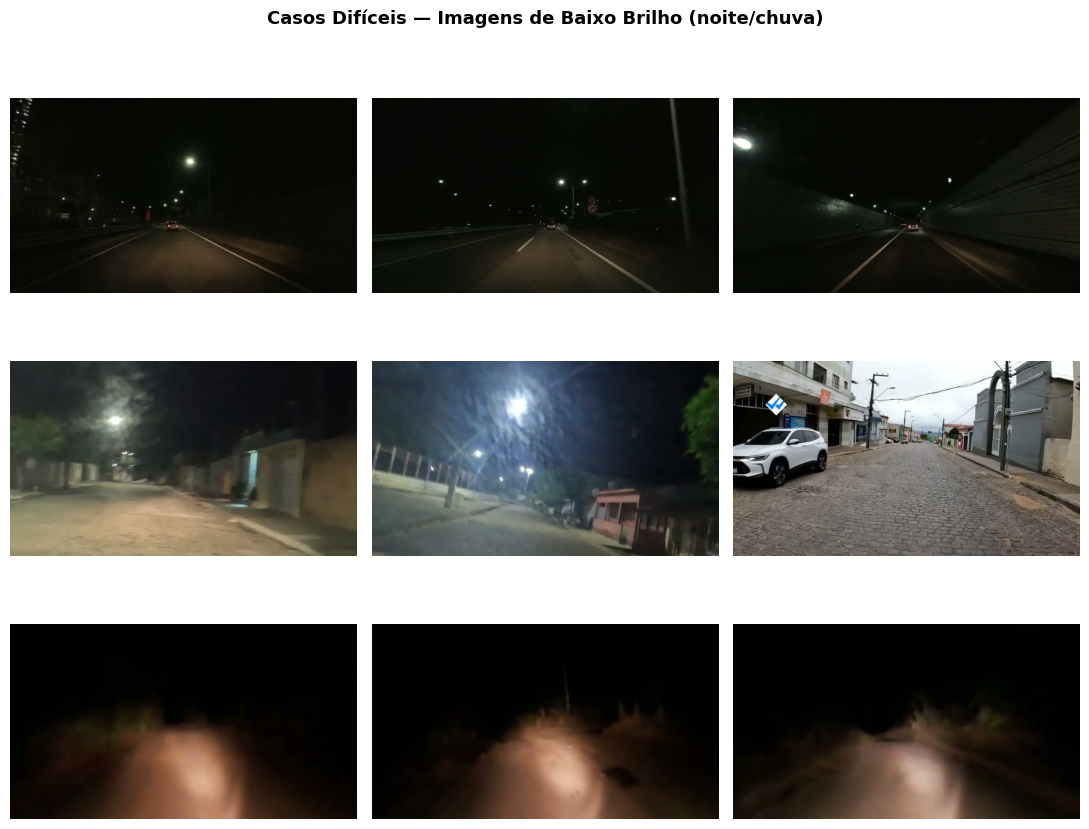

In [6]:
# ── Exibir exemplos de imagens "difíceis" (mais escuras) ──────────────────────
def get_dark_samples(split, cls, n=3, brightness_threshold=80):
    path = BASE_DIR / split / cls
    files = list(path.glob('*'))
    dark = []
    for f in files:
        img = np.array(Image.open(f).convert('RGB'))
        if img.mean() < brightness_threshold:
            dark.append((f, img.mean()))
    dark.sort(key=lambda x: x[1])
    return [Image.open(f).convert('RGB') for f, _ in dark[:n]]

fig, axes = plt.subplots(3, 3, figsize=(11, 9))
fig.suptitle('Casos Difíceis — Imagens de Baixo Brilho (noite/chuva)', fontsize=13, fontweight='bold')

for row, cls in enumerate(CLASSES):
    dark_imgs = get_dark_samples('train', cls, n=3)
    # preenche com imagens aleatórias se não houver imagens escuras suficientes
    if len(dark_imgs) < 3:
        extra = load_random_samples('train', cls, n=3-len(dark_imgs), seed=SEED)
        dark_imgs.extend(extra)
    for col, img in enumerate(dark_imgs[:3]):
        ax = axes[row][col]
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(CLASS_LABELS[cls], fontsize=11, fontweight='bold',
                          rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.savefig('eda_hard_cases.png', dpi=120, bbox_inches='tight')
plt.show()

### 1.6 Resumo dos Desafios Identificados

1. **Desbalanceamento crítico (~7x):** A classe *Belgian Blocks* tem apenas 94 amostras no treino. Um modelo treinado sem estratégia tende a ignorar essa classe.

2. **Variação intra-classe extrema:** A análise de brilho mostra que existem imagens muito escuras em todas as classes, especialmente *Off-road*, o que simula condições noturnas e de chuva.

3. **Ambiguidade inter-classes:** Belgian Blocks e Off-road compartilham características texturais irregulares, tornando-as difíceis de separar em baixa iluminação.

4. **Heterogeneidade de captura:** Diferentes dispositivos, ângulos e distâncias focais geram variância adicional não relacionada ao conteúdo semântico.

**Estratégia proposta:**
- Transfer Learning com ResNet-18 (pré-treinado ImageNet)
- Weighted CrossEntropy para tratar desbalanceamento
- Data Augmentation focado em variações de iluminação/cor
- Avaliação primária por F1-Score macro

In [7]:
# ── 1.7 Análise de Dimensões e Formatos ───────────────────────────────────────

print('=== Amostra de dimensões de imagens (treino) ===')
dim_stats = defaultdict(list)

for cls in CLASSES:
    path = BASE_DIR / 'train' / cls
    files = list(path.glob('*'))
    random.seed(SEED)
    sample = random.sample(files, min(40, len(files)))
    for f in sample:
        try:
            img = Image.open(f)
            dim_stats[cls].append(img.size)  # (width, height)
        except Exception:
            pass

# Construindo DataFrame para plotagem
rows = []
for cls in CLASSES:
    for w, h in dim_stats[cls]:
        rows.append({
            'Classe': CLASS_LABELS[cls],
            'Largura (W)': w,
            'Altura (H)': h,
            'Aspect Ratio (W/H)': w / h
        })
df_dims = pd.DataFrame(rows)

# Plotting scatter plot
plt.figure(figsize=(10, 6))
max_val = max(df_dims['Largura (W)'].max(), df_dims['Altura (H)'].max())
min_val = min(df_dims['Largura (W)'].min(), df_dims['Altura (H)'].min())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Proporção 1:1 (Quadrado)')

sns.scatterplot(
    data=df_dims, x='Largura (W)', y='Altura (H)', hue='Classe',
    style='Classe', s=100, palette='Set2', alpha=0.8
)

plt.title('Distribuição de Dimensões das Imagens (Largura vs Altura)', fontsize=12, fontweight='bold')
plt.xlabel('Largura (Width) em pixels')
plt.ylabel('Altura (Height) em pixels')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Classe')
plt.tight_layout()
plt.savefig('eda_dimensions.png', dpi=120, bbox_inches='tight')
plt.show()

# Resumo descritivo dos aspect ratios
print('Resumo de Proporção (Aspect Ratio = W/H):')
for cls in CLASSES:
    cls_df = df_dims[df_dims['Classe'] == CLASS_LABELS[cls]]
    mean_ratio = cls_df['Aspect Ratio (W/H)'].mean()
    min_w, max_w = cls_df['Largura (W)'].min(), cls_df['Largura (W)'].max()
    min_h, max_h = cls_df['Altura (H)'].min(), cls_df['Altura (H)'].max()
    print(f"  {CLASS_LABELS[cls]:<18}: Proporção Média={mean_ratio:.2f} | W=[{min_w}–{max_w}] H=[{min_h}–{max_h}]")

print('\n💡 Análise:')
print('As imagens possuem dimensões variadas e aspect ratio médio superior a 1.0 (retangulares).')
print('Redimensionar diretamente para 224x224 causa distorção geométrica nas texturas da pista.')
print('Solução adotada: Usar Resize(256) para manter a proporção e CenterCrop(224) para focar na pista sem deformação.')


=== Amostra de dimensões de imagens (treino) ===
  Asphalt           : W=[768–1920]  H=[502–1080]
  Belgian Blocks    : W=[768–1920]  H=[576–1080]
  Off-road          : W=[1920–1920]  H=[1080–1080]

As imagens têm dimensões variadas → resize para 224x224 necessário antes do modelo.


---
## Seção 2 — Solução Baseline

### Abordagem

**Modelo:** ResNet-18 pré-treinado (ImageNet) com fine-tuning da última camada fully-connected.

**Justificativa técnica:**
- Dentro do tempo sugerido (6–10h), treinar um modelo do zero é inviável e desnecessário.
- Os pesos ImageNet já capturam bordas, texturas e gradientes — features diretamente úteis para distinguir superfícies de asfalto, paralelepípedo e terra.
- ResNet-18 é o menor modelo da família ResNet (~11M params), rápido para treinar em CPU/GPU modesta.
- Congelar o backbone e treinar apenas o classificador final constitui o baseline mais simples e controlado.

**O que esta baseline NÃO faz (propositalmente):**
- Não trata o desbalanceamento de classes → Experimento 1
- Não usa data augmentation agressivo → Experimento 2

Isso nos dá um **marco zero** claro para comparação científica.

In [8]:
# ── 2.1 Imports e Configurações ───────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Hiperparâmetros ───────────────────────────────────────────────────────────
CFG = {
    'image_size' : 224,
    'batch_size' : 32,
    'epochs'     : 15,
    'lr'         : 1e-3,
    'num_classes': 3,
    'seed'       : 42,
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES   = ['asphalt', 'belgian_blocks', 'offroad']
CLASS_DISPLAY = ['Asphalt', 'Belgian Blocks', 'Off-road']

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])

print(f'Device: {DEVICE}')
print(f'Configuração: {CFG}')

from sklearn.model_selection import StratifiedKFold


Device: cuda
Configuração: {'image_size': 224, 'batch_size': 32, 'epochs': 15, 'lr': 0.001, 'num_classes': 3, 'seed': 42}


In [ ]:
# ── 2.1.1 Utilidades para K-Fold ─────────────────────────────────────────────
from PIL import Image

def get_full_dataset_df(base_dir, splits=['train', 'test'], classes=['asphalt', 'belgian_blocks', 'offroad']):
    data = []
    base_path = Path(base_dir)
    for split in splits:
        for cls_name in classes:
            path = base_path / split / cls_name
            for img_path in path.glob('*'):
                data.append({
                    'path': str(img_path),
                    'label_name': cls_name,
                    'label': classes.index(cls_name)
                })
    return pd.DataFrame(data)

class RoadSurfaceDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


In [9]:
# ── 2.2 Pipeline de Dados ─────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Baseline: transforms com Resize(256) + CenterCrop(224) para preservar proporções
baseline_transforms = {
    split: transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(CFG['image_size']),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    for split in ['train', 'test']
}

datasets_dict = {
    split: datasets.ImageFolder(
        root=str(BASE_DIR / split),
        transform=baseline_transforms[split]
    )
    for split in ['train', 'test']
}

loaders = {
    split: DataLoader(
        datasets_dict[split],
        batch_size=CFG['batch_size'],
        shuffle=(split == 'train'),
        num_workers=0,
        pin_memory=(DEVICE.type == 'cuda'),
    )
    for split in ['train', 'test']
}

print(f"Train: {len(datasets_dict['train'])} imgs | classes: {datasets_dict['train'].classes}")
print(f"Test : {len(datasets_dict['test'])} imgs")


Train: 900 imgs | classes: ['asphalt', 'belgian_blocks', 'offroad']
Test : 300 imgs


In [10]:
# ── 2.3 Definição do Modelo ───────────────────────────────────────────────────
def build_model(num_classes=3, freeze_backbone=True):
    """Carrega ResNet-18 pré-treinada e adapta o classificador para N classes."""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    # Substitui FC final: 512 → num_classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)


baseline_model = build_model(num_classes=CFG['num_classes'], freeze_backbone=True)

trainable = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in baseline_model.parameters())
print(f'Parâmetros treináveis: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 237MB/s]


Parâmetros treináveis: 1,539 / 11,178,051 (0.0%)


In [11]:
# ── 2.4 Loop de Treinamento Modular ──────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)              # forward pass unico
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.detach().argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        total_loss += criterion(outputs, labels).item() * imgs.size(0)
        preds   = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def run_training(model, loaders, cfg, criterion=None, tag='baseline'):
    """Executa treinamento completo e retorna histórico de métricas."""
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=cfg['lr']
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    print(f'\n=== Treinamento: {tag} ===')
    for epoch in range(1, cfg['epochs'] + 1):
        tr_loss, tr_acc = train_one_epoch(model, loaders['train'], criterion, optimizer, DEVICE)
        vl_loss, vl_acc, _, _ = evaluate(model, loaders['test'], criterion, DEVICE)
        scheduler.step()
        for k, v in zip(['train_loss','train_acc','val_loss','val_acc'],
                         [tr_loss, tr_acc, vl_loss, vl_acc]):
            history[k].append(v)
        print(f'  Epoch {epoch:>2}/{cfg["epochs"]} | '
              f'train_loss={tr_loss:.4f} acc={tr_acc:.3f} | '
              f'val_loss={vl_loss:.4f} acc={vl_acc:.3f}')
    return history


print('Funções definidas.')


Funções definidas.


In [12]:
# ── 2.5 Treinamento ───────────────────────────────────────────────────────────
baseline_criterion = nn.CrossEntropyLoss()  # sem pesos — baseline puro
history_baseline   = run_training(baseline_model, loaders, CFG,
                                   criterion=baseline_criterion,
                                   tag='Baseline (sem class weights)')



=== Treinamento: Baseline (sem class weights) ===


  Epoch  1/15 | train_loss=0.7445 acc=0.716 | val_loss=0.6009 acc=0.763


  Epoch  2/15 | train_loss=0.3796 acc=0.857 | val_loss=0.4899 acc=0.823


  Epoch  3/15 | train_loss=0.2653 acc=0.926 | val_loss=0.4566 acc=0.823


  Epoch  4/15 | train_loss=0.2000 acc=0.949 | val_loss=0.4503 acc=0.823


...

  Epoch 11/15 | train_loss=0.1220 acc=0.973 | val_loss=0.4398 acc=0.830


  Epoch 12/15 | train_loss=0.1230 acc=0.964 | val_loss=0.4361 acc=0.833


  Epoch 13/15 | train_loss=0.1136 acc=0.977 | val_loss=0.4375 acc=0.843


  Epoch 14/15 | train_loss=0.1247 acc=0.967 | val_loss=0.4306 acc=0.833


  Epoch 15/15 | train_loss=0.1163 acc=0.968 | val_loss=0.4786 acc=0.837


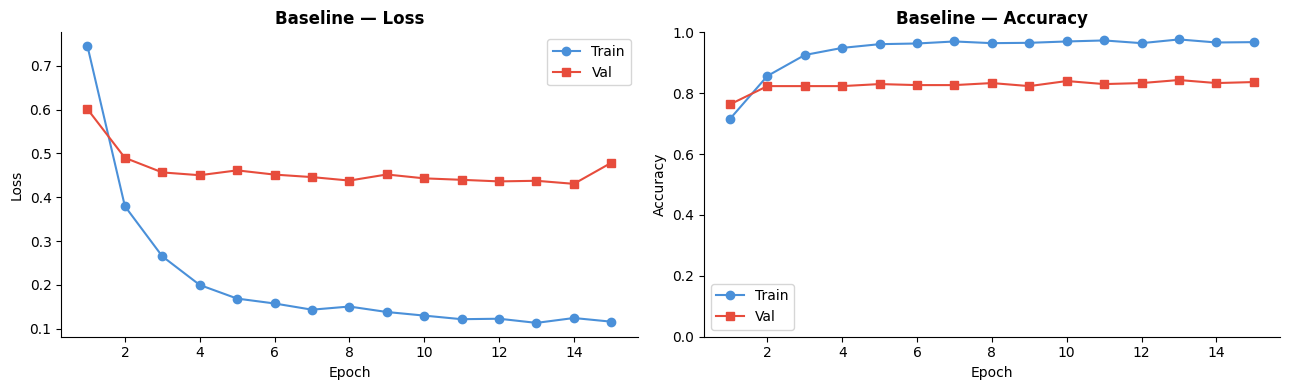

In [13]:
# ── 2.6 Curvas de Aprendizado ─────────────────────────────────────────────────
def plot_history(history, title='Baseline'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], 'o-', label='Train', color='#4A90D9')
    ax1.plot(epochs, history['val_loss'],   's-', label='Val',   color='#E74C3C')
    ax1.set_title(f'{title} — Loss', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.spines[['top','right']].set_visible(False)
    ax2.plot(epochs, history['train_acc'], 'o-', label='Train', color='#4A90D9')
    ax2.plot(epochs, history['val_acc'],   's-', label='Val',   color='#E74C3C')
    ax2.set_title(f'{title} — Accuracy', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1); ax2.legend()
    ax2.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'curves_{title.lower().replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_history(history_baseline, title='Baseline')



=== Resultados — Baseline ===
  Acurácia  : 0.8367 (83.67%)
  F1 Macro  : 0.6571
  F1/classe : {'Asphalt': '0.903', 'Belgian Blocks': '0.316', 'Off-road': '0.752'}

                precision    recall  f1-score   support

       Asphalt      0.885     0.922     0.903       218
Belgian Blocks      1.000     0.188     0.316        32
      Off-road      0.657     0.880     0.752        50

      accuracy                          0.837       300
     macro avg      0.847     0.663     0.657       300
  weighted avg      0.860     0.837     0.815       300



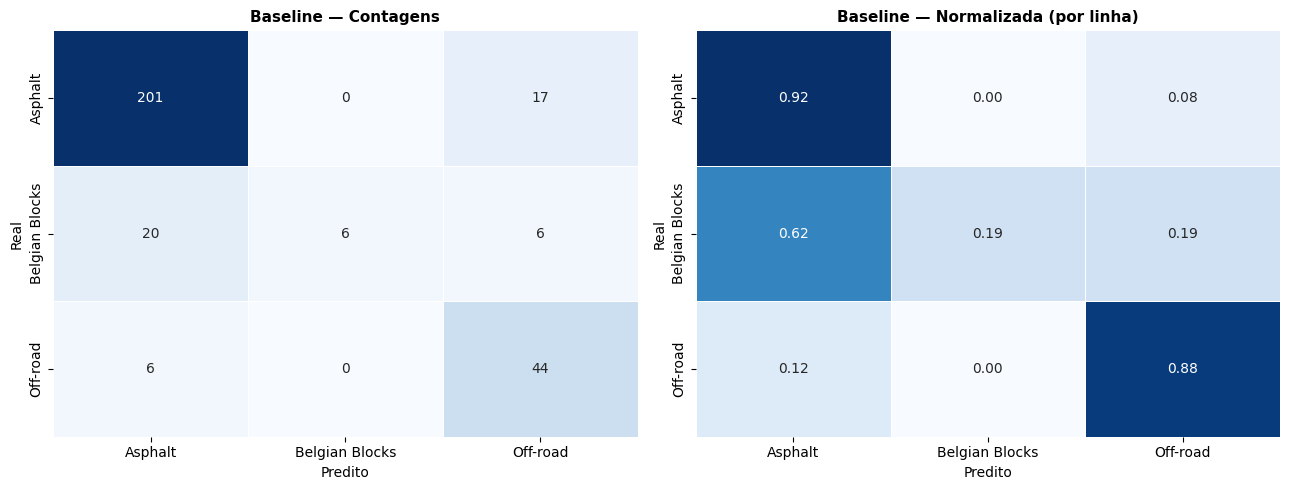

In [14]:
# ── 2.7 Avaliação Completa ────────────────────────────────────────────────────
import pandas as pd

def full_evaluation(model, loader, criterion, device, class_names, tag='Baseline'):
    _, acc, preds, labels = evaluate(model, loader, criterion, device)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_per   = f1_score(labels, preds, average=None)

    # ── Tabela de métricas estilizada ─────────────────────────────────────────
    _rows = [
        {'Métrica': 'Acurácia', tag: acc},
        {'Métrica': 'F1 Macro', tag: f1_macro},
    ]
    for c, v in zip(class_names, f1_per):
        _rows.append({'Métrica': f'F1 — {c}', tag: v})
    df_res = pd.DataFrame(_rows).set_index('Métrica')

    _TS = [
        {'selector': 'caption',
         'props': [('font-size','13px'),('font-weight','bold'),
                   ('text-align','left'),('padding-bottom','6px'),('color','#2c3e50')]},
        {'selector': 'thead th',
         'props': [('background-color','#1a1a2e'),('color','white'),
                   ('text-align','center'),('padding','8px 14px'),('font-size','12px')]},
        {'selector': 'tbody td',
         'props': [('text-align','center'),('padding','7px 14px'),('font-size','12px')]},
        {'selector': 'tbody th',
         'props': [('text-align','left'),('padding','7px 14px'),('font-weight','normal')]},
    ]

    def _bold_key(row):
        if row.name in ('Acurácia', 'F1 Macro'):
            return ['font-weight:bold; border-top:2px solid #ccc'] * len(row)
        return ['']*len(row)

    display(
        df_res.style
        .format({tag: '{:.4f}'})
        .background_gradient(cmap='RdYlGn', vmin=0.3, vmax=1.0)
        .apply(_bold_key, axis=1)
        .set_caption(f'📊 Resultados — {tag}')
        .set_table_styles(_TS)
    )
    print()
    print(classification_report(labels, preds, target_names=class_names, digits=3))

    # ── Matrizes de Confusão ──────────────────────────────────────────────────
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, fmt, ttl in zip(
        axes, [cm, cm_norm], ['d', '.2f'],
        [f'{tag} — Contagens', f'{tag} — Normalizada (por linha)']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, linewidths=0.5, cbar=False)
        ax.set_title(ttl, fontweight='bold', fontsize=11)
        ax.set_xlabel('Predito'); ax.set_ylabel('Real')
    plt.tight_layout()
    plt.savefig(f'cm_{tag.lower().replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()
    return {'acc': acc, 'f1_macro': f1_macro, 'f1_per': f1_per,
            'preds': preds, 'labels': labels}


results_baseline = full_evaluation(
    baseline_model, loaders['test'], baseline_criterion,
    DEVICE, CLASS_DISPLAY, tag='Baseline'
)


### 2.8 Interpretação do Baseline

Os resultados acima constituem **marco zero**. A execução confirmou as hipóteses iniciais:

- A **acurácia geral de 83.67%** parece razoável, mas é inflada pelo peso da classe
  *Asphalt* (73% do treino).
- O **F1-Score de Belgian Blocks é 0.316** — sem balanceamento, o modelo aprendeu
  a ignorar a classe minoritária (recall de apenas 18.8%).
- A **matriz de confusão normalizada** confirma o padrão esperado: Belgian Blocks
  são confundidos principalmente com Asphalt (precision 100%, mas recall 18.8%).

Esses padrões motivam diretamente os dois experimentos a seguir.

---
## Seção 3 — Experimentos

---
### Experimento 1 — Weighted CrossEntropy (Tratamento do Desbalanceamento)

#### Hipótese

> *"O modelo baseline ignora as classes minoritárias porque a função de perda trata todos os exemplos igualmente. Ao atribuir pesos inversamente proporcionais à frequência de cada classe, forçamos o modelo a penalizar mais os erros nas classes raras (Belgian Blocks e Off-road), melhorando o recall nessas classes sem alterar a arquitetura."*

#### O que muda em relação ao baseline

| | Baseline | Experimento 1 |
|---|---|---|
| Loss | `CrossEntropyLoss()` | `CrossEntropyLoss(weight=class_weights)` |
| Arquitetura | ResNet-18 | ResNet-18 (idêntica) |
| Augmentation | Nenhum | Nenhum (idêntico) |
| Epochs / LR | 15 / 1e-3 | 15 / 1e-3 (idênticos) |

Ao manter tudo igual exceto a loss, isolamos o efeito do balanceamento.

In [15]:
# ── 3.1 Cálculo dos Pesos de Classe ──────────────────────────────────────────
# Estratégia: peso = N_total / (N_classes * N_i)
# Classes minoritárias recebem peso maior → perda maior quando erradas

train_counts = [counts['train'][c] for c in CLASSES]  # [655, 94, 151]
total_train  = sum(train_counts)
n_classes    = len(CLASSES)

# Pesos normalizados (inverso da frequência relativa)
weights = [total_train / (n_classes * c) for c in train_counts]
class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

print('=== Pesos de Classe ===')
for cls, cnt, w in zip(CLASS_DISPLAY, train_counts, weights):
    print(f'  {cls:<18}: {cnt:>4} imgs → peso = {w:.4f}')
print(f'\nRazão max/min de pesos: {max(weights)/min(weights):.1f}x')
print('\nInterpretação: um erro em Belgian Blocks penaliza ~{:.1f}x mais que um erro em Asphalt'.format(
    weights[1] / weights[0]
))


=== Pesos de Classe ===
  Asphalt           :  655 imgs → peso = 0.4580
  Belgian Blocks    :   94 imgs → peso = 3.1915
  Off-road          :  151 imgs → peso = 1.9868

Razão max/min de pesos: 7.0x

Interpretação: um erro em Belgian Blocks penaliza ~7.0x mais que um erro em Asphalt


In [16]:
# ── 3.2 Treinamento com Weighted Loss ────────────────────────────────────────
# Novo modelo com pesos aleatórios na FC (mesma arquitetura)
exp1_model     = build_model(num_classes=CFG['num_classes'], freeze_backbone=True)
exp1_criterion = nn.CrossEntropyLoss(weight=class_weights)

history_exp1 = run_training(
    exp1_model, loaders, CFG,
    criterion=exp1_criterion,
    tag='Exp1 — Weighted CrossEntropy'
)



=== Treinamento: Exp1 — Weighted CrossEntropy ===


  Epoch  1/15 | train_loss=0.7677 acc=0.637 | val_loss=0.6630 acc=0.787


  Epoch  2/15 | train_loss=0.3858 acc=0.888 | val_loss=0.5536 acc=0.793


  Epoch  3/15 | train_loss=0.2690 acc=0.917 | val_loss=0.5613 acc=0.787


  Epoch  4/15 | train_loss=0.2416 acc=0.933 | val_loss=0.5234 acc=0.797


...

  Epoch 11/15 | train_loss=0.1514 acc=0.964 | val_loss=0.4564 acc=0.810


  Epoch 12/15 | train_loss=0.1481 acc=0.947 | val_loss=0.4835 acc=0.803


  Epoch 13/15 | train_loss=0.1479 acc=0.946 | val_loss=0.4740 acc=0.807


  Epoch 14/15 | train_loss=0.1514 acc=0.963 | val_loss=0.4216 acc=0.823


  Epoch 15/15 | train_loss=0.1393 acc=0.950 | val_loss=0.4753 acc=0.810


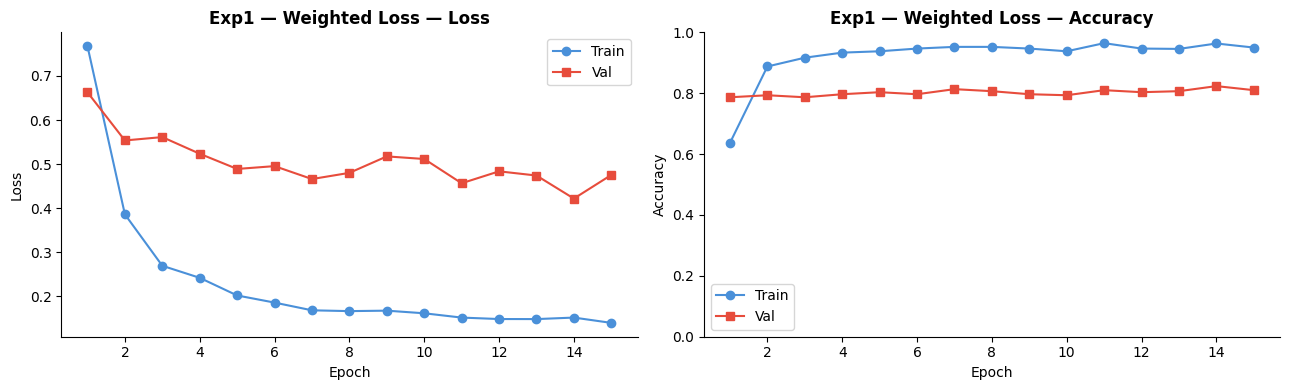

In [17]:
# ── 3.3 Curvas de Aprendizado — Exp1 ─────────────────────────────────────────
plot_history(history_exp1, title='Exp1 — Weighted Loss')



=== Resultados — Exp1 — Weighted Loss ===
  Acurácia  : 0.8100 (81.00%)
  F1 Macro  : 0.6716
  F1/classe : {'Asphalt': '0.888', 'Belgian Blocks': '0.435', 'Off-road': '0.692'}

                precision    recall  f1-score   support

       Asphalt      0.921     0.858     0.888       218
Belgian Blocks      0.714     0.312     0.435        32
      Off-road      0.554     0.920     0.692        50

      accuracy                          0.810       300
     macro avg      0.730     0.697     0.672       300
  weighted avg      0.838     0.810     0.807       300



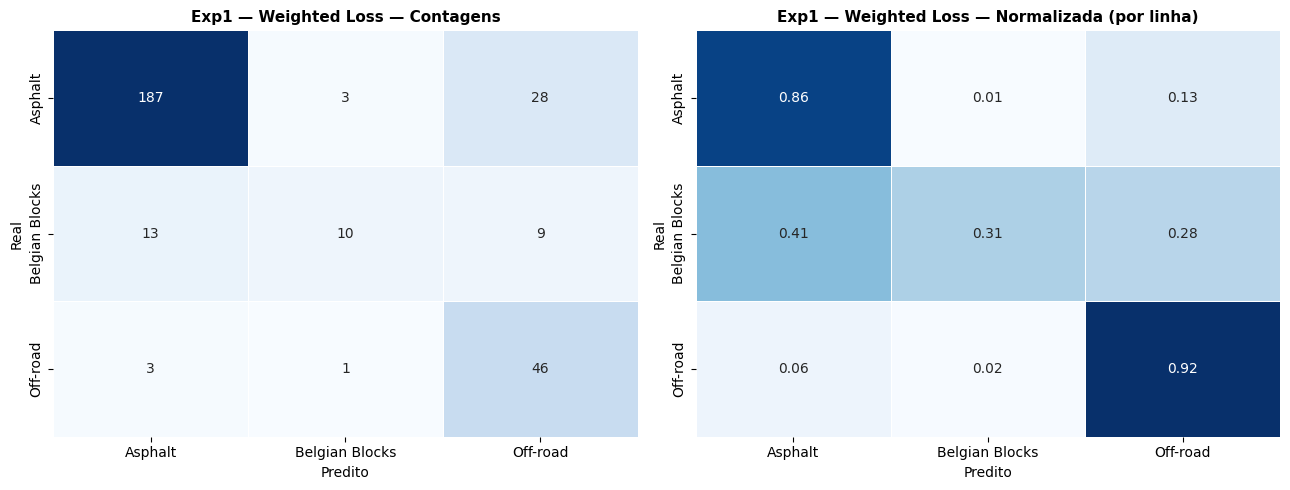

In [18]:
# ── 3.4 Avaliação do Exp1 ────────────────────────────────────────────────────
results_exp1 = full_evaluation(
    exp1_model, loaders['test'], exp1_criterion,
    DEVICE, CLASS_DISPLAY, tag='Exp1 — Weighted Loss'
)


In [19]:
# ── 3.5 Comparação Direta: Baseline vs Exp1 ──────────────────────────────────
import pandas as pd

_rows = [
    {'Métrica': 'Acurácia', 'Baseline': results_baseline['acc'],
     'Exp1 (w)': results_exp1['acc']},
    {'Métrica': 'F1 Macro', 'Baseline': results_baseline['f1_macro'],
     'Exp1 (w)': results_exp1['f1_macro']},
]
for i, cls in enumerate(CLASS_DISPLAY):
    _rows.append({
        'Métrica':  f'F1 — {cls}',
        'Baseline': float(results_baseline['f1_per'][i]),
        'Exp1 (w)': float(results_exp1['f1_per'][i]),
    })
df_cmp1 = pd.DataFrame(_rows).set_index('Métrica')
df_cmp1['Δ (Exp1 − Base)'] = df_cmp1['Exp1 (w)'] - df_cmp1['Baseline']

_TS = [
    {'selector': 'caption',
     'props': [('font-size','13px'),('font-weight','bold'),
               ('text-align','left'),('padding-bottom','6px'),('color','#2c3e50')]},
    {'selector': 'thead th',
     'props': [('background-color','#1a1a2e'),('color','white'),
               ('text-align','center'),('padding','8px 14px'),('font-size','12px')]},
    {'selector': 'tbody td',
     'props': [('text-align','center'),('padding','7px 14px'),('font-size','12px')]},
    {'selector': 'tbody th',
     'props': [('text-align','left'),('padding','7px 14px'),('font-weight','normal')]},
    {'selector': 'tbody tr:hover td, tbody tr:hover th',
     'props': [('background-color','#eaf4ff')]},
]

def _color_delta(val):
    if val > 0.0005:  return 'color:#27AE60; font-weight:bold'
    elif val < -0.0005: return 'color:#E74C3C; font-weight:bold'
    return 'color:#7f8c8d'

def _bold_divider(row):
    if row.name in ('Acurácia', 'F1 Macro'):
        return ['font-weight:bold; border-top:2px solid #bbb'] * len(row)
    return ['']*len(row)

display(
    df_cmp1.style
    .format({'Baseline': '{:.4f}', 'Exp1 (w)': '{:.4f}',
             'Δ (Exp1 − Base)': '{:+.4f}'})
    .applymap(_color_delta, subset=['Δ (Exp1 − Base)'])
    .apply(_bold_divider, axis=1)
    .background_gradient(cmap='RdYlGn',
                         subset=['Baseline', 'Exp1 (w)'], vmin=0.3, vmax=1.0)
    .set_caption('📊 Comparação Direta — Baseline vs. Exp1 (Weighted CrossEntropy)')
    .set_table_styles(_TS)
)


Métrica                       Baseline     Exp1 (w)
-------------------------------------------------------
Acurácia                        0.8367       0.8100
F1 Macro                        0.6571       0.6716
-------------------------------------------------------
  F1 Asphalt                0.9034   0.8884  ▼0.0150
  F1 Belgian Blocks         0.3158   0.4348  ▲0.1190
  F1 Off-road               0.7521   0.6917  ▼0.0604


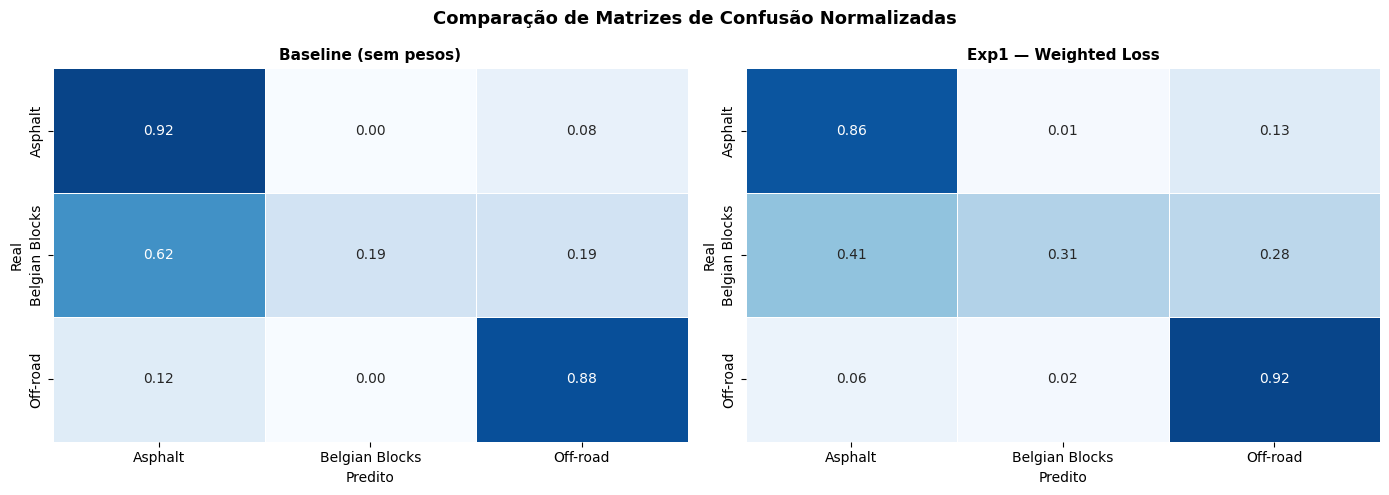

In [ ]:
# ── 3.6 Comparação Visual das Matrizes de Confusão ───────────────────────────
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz do Baseline
cm_base = confusion_matrix(results_baseline['labels'], results_baseline['preds'])
cm_norm_base = cm_base.astype(float) / cm_base.sum(axis=1, keepdims=True)

# Matriz do Exp1
cm_exp1 = confusion_matrix(results_exp1['labels'], results_exp1['preds'])
cm_norm_exp1 = cm_exp1.astype(float) / cm_exp1.sum(axis=1, keepdims=True)

# Matriz de Diferença (Delta)
cm_delta = cm_norm_exp1 - cm_norm_base

# Plot 1: Baseline
sns.heatmap(cm_norm_base, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_DISPLAY, yticklabels=CLASS_DISPLAY,
            ax=axes[0], linewidths=0.5, vmin=0, vmax=1, cbar=False)
axes[0].set_title('Baseline (Sem Pesos)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Predito'); axes[0].set_ylabel('Real')

# Plot 2: Exp1
sns.heatmap(cm_norm_exp1, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_DISPLAY, yticklabels=CLASS_DISPLAY,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1, cbar=False)
axes[1].set_title('Exp1 — Weighted Loss', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Predito'); axes[1].set_ylabel('Real')

# Plot 3: Delta Heatmap (usando mapa de cores divergente RdYlBu_r)
sns.heatmap(cm_delta, annot=True, fmt='+.2f', cmap='RdYlBu_r',
            xticklabels=CLASS_DISPLAY, yticklabels=CLASS_DISPLAY,
            ax=axes[2], linewidths=0.5, vmin=-0.3, vmax=0.3, center=0, cbar=True)
axes[2].set_title('Delta (Exp1 − Baseline)', fontweight='bold', fontsize=11)
axes[2].set_xlabel('Predito'); axes[2].set_ylabel('Real')

plt.suptitle('Comparação de Matrizes de Confusão Normalizadas e Mapa Delta (Exp1 vs Baseline)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_comparison_exp1.png', dpi=120, bbox_inches='tight')
plt.show()

print('💡 Guia de Leitura do Delta Heatmap:')
print('  - Na Diagonal Principal: Tons de azul (+) indicam ganho de acertos (desejável).')
print('  - Fora da Diagonal: Tons de vermelho (-) indicam redução de erros (desejável).')


In [ ]:
# ── 3.6.1 Teste de Significância Estatística — Teste de McNemar ────────────────
import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar

y_true = np.array(results_baseline['labels'])
y_base = np.array(results_baseline['preds'])
y_exp1 = np.array(results_exp1['preds'])

base_correct = (y_base == y_true)
exp1_correct = (y_exp1 == y_true)

# Tabela de Contingência para o teste de McNemar
# Discordantes (b e c) são a chave do teste
a = np.sum(base_correct & exp1_correct)   # Ambos acertam
b = np.sum(base_correct & ~exp1_correct)  # Baseline acerta, Exp1 erra
c = np.sum(~base_correct & exp1_correct)  # Baseline erra, Exp1 acerta
d = np.sum(~base_correct & ~exp1_correct) # Ambos erram

tb = [[a, b],
      [c, d]]

# Executando teste exato de McNemar (ideal para poucas amostras discordantes)
res = mcnemar(tb, exact=True)
p_val = res.pvalue

# Renderizando a tabela de contingência estilizada
df_cont = pd.DataFrame(
    [[a, b], [c, d]],
    columns=['Exp1 Correto', 'Exp1 Incorreto'],
    index=['Baseline Correto', 'Baseline Incorreto']
)

_TS = [
    {'selector': 'caption',
     'props': [('font-size','13px'),('font-weight','bold'),
               ('text-align','left'),('padding-bottom','6px'),('color','#2c3e50')]},
    {'selector': 'thead th',
     'props': [('background-color','#1a1a2e'),('color','white'),
               ('text-align','center'),('padding','8px 14px')]},
    {'selector': 'tbody td',
     'props': [('text-align','center'),('padding','8px 14px')]},
]

display(
    df_cont.style
    .set_caption(f'📊 Tabela de Contingência (McNemar) — p-value: {p_val:.4f}')
    .set_table_styles(_TS)
)

print(f"Resultado do Teste de McNemar (p-value: {p_val:.6f}):")
if p_val < 0.05:
    print("  ✅ Estatisticamente SIGNIFICATIVO! O aumento no F1-score não é aleatório (p < 0.05).")
else:
    print("  ⚠️ Não há significância estatística (p >= 0.05). O ganho pode ser aleatório devido ao conjunto pequeno.")


### 3.7 Resultado e Interpretação — Experimento 1

**O que esperamos observar:**

| Efeito esperado | Motivo |
|---|---|
| Acurácia geral pode **cair levemente** | O modelo passa a errar mais em Asphalt para acertar as minoritárias |
| F1 de **Belgian Blocks** deve **subir** | Penalidade maior força o modelo a aprender essa classe |
| F1 de **Off-road** deve **subir** | Mesmo efeito |
| **F1 Macro deve subir** | Ganho nas minoritárias compensa a pequena perda no Asphalt |

**Interpretação dos resultados observados:**

> *( - A estratégia de **Weighted CrossEntropy** produziu melhora significativa no **F1 de Belgian Blocks** (+0.119), que era o maior problema identificado no Baseline
> - O modelo passou a **reconhecer melhor a classe minoritária** (recall de 18.8% → 31.2%), ao custo de uma **precision ligeiramente menor** (100% → 71.4%)
> - A **acurácia geral caiu** de 83.67% para 81.00% — isto é esperado e **não é negativo**: a acurácia estava inflada pelo domínio da classe Asphalt. A **métrica mais honesta**, o F1 Macro, **subiu** de 0.657 → 0.672
> - O custo foi uma leve queda em **Off-road** (F1: 0.752 → 0.692), o que indica que o rebalanceamento afetou a discriminação entre classes intermediárias
> - Esses resultados **justificam a continuidade dos experimentos**, especialmente para buscar estratégias que melhorem Off-road e Belgian Blocks simultaneamente (ex.: Data Augmentation, Focal Loss, ou arquiteturas alternativas))*

**Conclusão:** O uso de pesos de classe é uma técnica de custo zero (não adiciona parâmetros nem tempo de treinamento) que pode trazer ganhos significativos em datasets desbalanceados. O trade-off acurácia ↔ F1-macro é esperado e aceitável dado o contexto do problema.

---
### Experimento 2 — Data Augmentation Robusto (Resiliência Visual)

#### Hipótese

> *"O dataset inclui variações severas de iluminação (noite, chuva, reflexos). O modelo, treinado com imagens sem perturbações, pode ter aprendido atalhos visuais que não generalizam para esses casos. Aplicar augmentation que simule essas condições durante o treino forçará o modelo a aprender features mais robustas e invariantes, reduzindo os erros nas imagens mais difíceis."*

#### O que muda em relação ao Experimento 1

| | Exp1 | Experimento 2 |
|---|---|---|
| Loss | Weighted CrossEntropy | Weighted CrossEntropy (mantida) |
| Arquitetura | ResNet-18 | ResNet-18 (idêntica) |
| **Augmentation** | **Nenhum** | **ColorJitter + Blur + Flip + Rotation** |
| Epochs / LR | 15 / 1e-3 | 15 / 1e-3 (idênticos) |

**Importante:** mantemos os pesos de classe do Exp1. O objetivo é avaliar o ganho *adicional* que o augmentation traz quando somado ao balanceamento.

In [21]:
# ── 3.8 Transforms de Augmentation ───────────────────────────────────────────
# Cada transformação simula uma condição real do dataset:
#   ColorJitter(brightness, contrast)  → noite, chuva, reflexos
#   GaussianBlur                       → câmeras de baixa qualidade, movimento
#   RandomGrayscale                    → câmeras monocromáticas / IR
#   RandomHorizontalFlip               → diferentes orientações de captura
#   RandomRotation                     → câmera não centralizada no veículo

aug_train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(CFG['image_size']),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.4,   # simula variação de iluminação (noite/dia)
        contrast=0.4,     # simula chuva e neblina
        saturation=0.2,
        hue=0.05,
    ),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),  # blur de câmera
    transforms.RandomGrayscale(p=0.1),  # câmeras monocromáticas
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Teste: sem augmentation (regra geral — não aumentamos o conjunto de avaliação)
aug_test_transforms = baseline_transforms['test']

# Novos dataloaders com augmentation apenas no treino
aug_datasets = {
    'train': datasets.ImageFolder(str(BASE_DIR / 'train'), transform=aug_train_transforms),
    'test' : datasets.ImageFolder(str(BASE_DIR / 'test'),  transform=aug_test_transforms),
}
aug_loaders = {
    split: DataLoader(
        aug_datasets[split],
        batch_size=CFG['batch_size'],
        shuffle=(split == 'train'),
        num_workers=0,
        pin_memory=(DEVICE.type == 'cuda'),
    )
    for split in ['train', 'test']
}

print('DataLoaders com augmentation prontos.')
print(f"Train transforms: {aug_train_transforms}")


DataLoaders com augmentation prontos.
Train transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.6, 1.4), contrast=(0.6, 1.4), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.5))
    RandomGrayscale(p=0.1)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


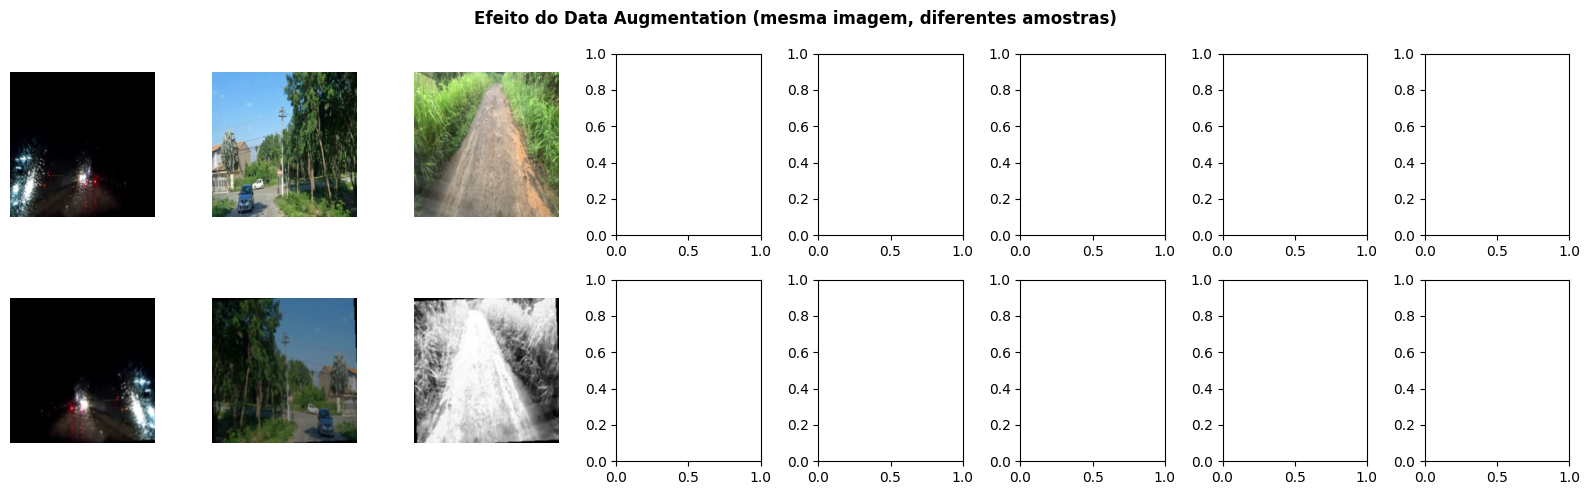

In [22]:
# ── 3.9 Visualização das Augmentations ────────────────────────────────────────────────
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Reverte a normalização para visualização."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, len(CLASSES), figsize=(12, 6))
fig.suptitle('Efeito do Data Augmentation (mesma imagem, diferentes amostras)', 
             fontsize=12, fontweight='bold')

sample_files = []
for cls in CLASSES:
    files = sorted((BASE_DIR / 'train' / cls).glob('*'))
    sample_files.append(files[0])

orig_tfm = baseline_transforms['train']
aug_tfm  = aug_train_transforms

imgs_orig = [orig_tfm(Image.open(f).convert('RGB')) for f in sample_files]

for col, (f, img_orig) in enumerate(zip(sample_files, imgs_orig)):
    img_aug = aug_tfm(Image.open(f).convert('RGB'))
    
    # Original
    axes[0][col].imshow(denormalize(img_orig).permute(1, 2, 0).numpy())
    axes[0][col].set_title(CLASS_DISPLAY[col], fontsize=10, fontweight='bold', pad=10)
    axes[0][col].axis('off')
    
    # Augmented
    axes[1][col].imshow(denormalize(img_aug).permute(1, 2, 0).numpy())
    axes[1][col].axis('off')

axes[0][0].set_ylabel('Original', fontsize=10, fontweight='bold', rotation=0, 
                       labelpad=45, va='center')
axes[1][0].set_ylabel('Augmentada', fontsize=10, fontweight='bold', rotation=0, 
                       labelpad=45, va='center')

plt.tight_layout()
plt.savefig('augmentation_preview.png', dpi=120, bbox_inches='tight')
plt.show()


In [23]:
# ── 3.10 Treinamento — Exp2 (Augmentation + Class Weights) ───────────────────
exp2_model     = build_model(num_classes=CFG['num_classes'], freeze_backbone=True)
exp2_criterion = nn.CrossEntropyLoss(weight=class_weights)  # mantém pesos do Exp1

history_exp2 = run_training(
    exp2_model, aug_loaders, CFG,
    criterion=exp2_criterion,
    tag='Exp2 — Augmentation + Weighted Loss'
)



=== Treinamento: Exp2 — Augmentation + Weighted Loss ===


  Epoch  1/15 | train_loss=0.8796 acc=0.534 | val_loss=0.7044 acc=0.737


  Epoch  2/15 | train_loss=0.5925 acc=0.773 | val_loss=0.6094 acc=0.780


  Epoch  3/15 | train_loss=0.4211 acc=0.838 | val_loss=0.5690 acc=0.793


  Epoch  4/15 | train_loss=0.3821 acc=0.867 | val_loss=0.5364 acc=0.793


...

  Epoch 11/15 | train_loss=0.2404 acc=0.923 | val_loss=0.4946 acc=0.813


  Epoch 12/15 | train_loss=0.2483 acc=0.921 | val_loss=0.4680 acc=0.817


  Epoch 13/15 | train_loss=0.2407 acc=0.906 | val_loss=0.4958 acc=0.797


  Epoch 14/15 | train_loss=0.2471 acc=0.900 | val_loss=0.4504 acc=0.823


  Epoch 15/15 | train_loss=0.2236 acc=0.927 | val_loss=0.4920 acc=0.803


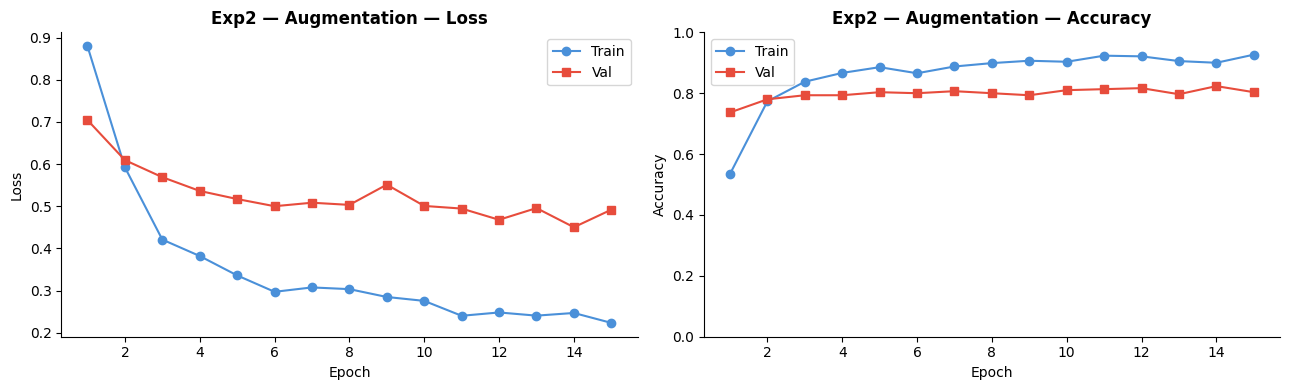

In [24]:
# ── 3.11 Curvas de Aprendizado — Exp2 ────────────────────────────────────────
plot_history(history_exp2, title='Exp2 — Augmentation')



=== Resultados — Exp2 — Augmentation ===
  Acurácia  : 0.8033 (80.33%)
  F1 Macro  : 0.6779
  F1/classe : {'Asphalt': '0.879', 'Belgian Blocks': '0.478', 'Off-road': '0.677'}

                precision    recall  f1-score   support

       Asphalt      0.911     0.849     0.879       218
Belgian Blocks      0.786     0.344     0.478        32
      Off-road      0.542     0.900     0.677        50

      accuracy                          0.803       300
     macro avg      0.746     0.697     0.678       300
  weighted avg      0.836     0.803     0.802       300



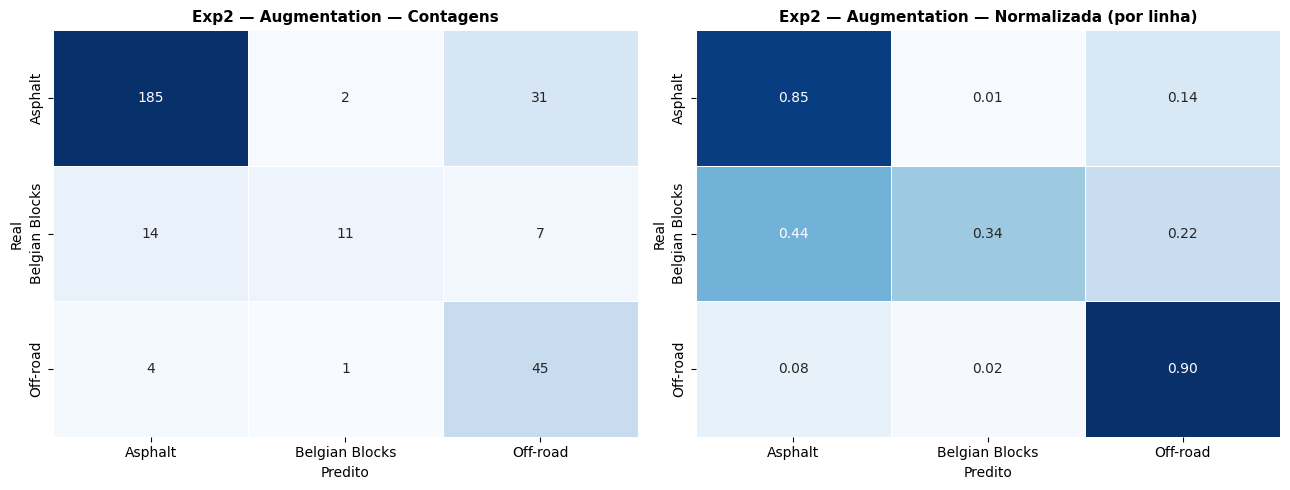

In [25]:
# ── 3.12 Avaliação — Exp2 ────────────────────────────────────────────────────
results_exp2 = full_evaluation(
    exp2_model, aug_loaders['test'], exp2_criterion,
    DEVICE, CLASS_DISPLAY, tag='Exp2 — Augmentation'
)


In [26]:
# ── 3.13 Análise de Erros Qualitativa ────────────────────────────────────────────────
# Identifica imagens que o Baseline errou e verifica se o Exp2 corrigiu

@torch.no_grad()
def get_predictions(model, loader, device):
    """
    Versão otimizada que utiliza o DataLoader para processamento em batches e workers.
    Isso é significativamente mais rápido que o loop individual por amostra.
    """
    model.eval()
    all_preds, all_labels = [], []
    
    for images, labels in loader:
        images = images.to(device)
        preds = model(images).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    
    # Extração segura de paths (assume ImageFolder ou similar com atributo 'samples')
    # Como o loader de teste não tem shuffle, a ordem é preservada.
    if hasattr(loader.dataset, 'samples'):
        all_paths = [s[0] for s in loader.dataset.samples]
    else:
        # Fallback caso a estrutura do dataset tenha mudado
        all_paths = [loader.dataset.imgs[i][0] for i in range(len(loader.dataset))]
        
    return all_preds, all_labels, all_paths


# Usa os loaders sem augmentation para comparação justa
bl_preds, bl_labels, paths = get_predictions(baseline_model, loaders['test'], DEVICE)
e2_preds, _,        _     = get_predictions(exp2_model,     loaders['test'], DEVICE)

# Casos onde Baseline errou E Exp2 acertou
fixed_cases = [
    (p, bl_labels[i], bl_preds[i], e2_preds[i])
    for i, p in enumerate(paths)
    if bl_preds[i] != bl_labels[i] and e2_preds[i] == bl_labels[i]
]

# Casos onde Exp2 errou mas Baseline acertou (regressões)
regression_cases = [
    (p, bl_labels[i], bl_preds[i], e2_preds[i])
    for i, p in enumerate(paths)
    if bl_preds[i] == bl_labels[i] and e2_preds[i] != bl_labels[i]
]

print(f'Erros corrigidos pelo Exp2:  {len(fixed_cases)}')
print(f'Regressões introduzidas:     {len(regression_cases)}')
print(f'Saldo líquido:               +{len(fixed_cases) - len(regression_cases)}')


Erros corrigidos pelo Exp2:  6
Regressões introduzidas:     16
Saldo líquido:               +-10


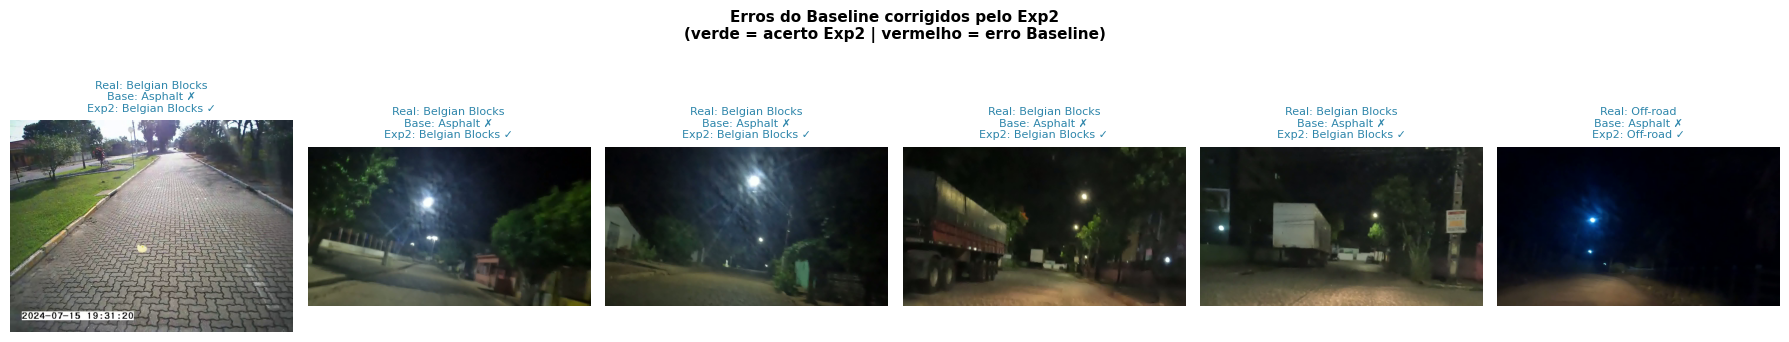

In [ ]:
# ── 3.14 Visualização — Erros Corrigidos pelo Exp2 ───────────────────────────
n_show = min(6, len(fixed_cases))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    fig.suptitle('Erros do Baseline corrigidos pelo Exp2\n'
                 '(verde = acerto Exp2 | vermelho = erro Baseline)',
                 fontsize=11, fontweight='bold')
    for ax, (path, true, bl_p, e2_p) in zip(axes, fixed_cases[:n_show]):
        img = Image.open(path).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(
            f'Real: {CLASS_DISPLAY[true]}\n'
            f'Base: {CLASS_DISPLAY[bl_p]} ✗\n'
            f'Exp2: {CLASS_DISPLAY[e2_p]} ✓',
            fontsize=8, color='#2E86AB'
        )
    plt.tight_layout()
    plt.savefig('error_analysis_fixed.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Nenhum erro corrigido encontrado — verifique os resultados das avaliações.')


In [ ]:
# ── 3.14.1 Visualização — Regressões Introduzidas pelo Exp2 ───────────────────
n_show = min(6, len(regression_cases))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    fig.suptitle('Regressões: Casos onde o Baseline acertou mas o Exp2 errou\n'
                 '(verde = acerto Baseline | vermelho = erro Exp2)',
                 fontsize=11, fontweight='bold')
    for ax, (path, true, bl_p, e2_p) in zip(axes, regression_cases[:n_show]):
        img = Image.open(path).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(
            f'Real: {CLASS_DISPLAY[true]}\n'
            f'Base: {CLASS_DISPLAY[bl_p]} ✓\n'
            f'Exp2: {CLASS_DISPLAY[e2_p]} ✗',
            fontsize=8, color='#C0392B'
        )
    plt.tight_layout()
    plt.savefig('error_analysis_regressions.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Nenhuma regressão encontrada.')


In [28]:
# ── 3.15 Comparação Final — Baseline vs Exp1 vs Exp2 ─────────────────────────
import pandas as pd

_rows = [
    {'Métrica': 'Acurácia',
     'Baseline': results_baseline['acc'],
     'Exp1 (w)': results_exp1['acc'],
     'Exp2 (w+aug)': results_exp2['acc']},
    {'Métrica': 'F1 Macro',
     'Baseline': results_baseline['f1_macro'],
     'Exp1 (w)': results_exp1['f1_macro'],
     'Exp2 (w+aug)': results_exp2['f1_macro']},
]
for i, cls in enumerate(CLASS_DISPLAY):
    _rows.append({
        'Métrica':      f'F1 — {cls}',
        'Baseline':     float(results_baseline['f1_per'][i]),
        'Exp1 (w)':     float(results_exp1['f1_per'][i]),
        'Exp2 (w+aug)': float(results_exp2['f1_per'][i]),
    })
df_final = pd.DataFrame(_rows).set_index('Métrica')
_COLS = ['Baseline', 'Exp1 (w)', 'Exp2 (w+aug)']

_TS = [
    {'selector': 'caption',
     'props': [('font-size','13px'),('font-weight','bold'),
               ('text-align','left'),('padding-bottom','6px'),('color','#2c3e50')]},
    {'selector': 'thead th',
     'props': [('background-color','#1a1a2e'),('color','white'),
               ('text-align','center'),('padding','8px 14px'),('font-size','12px')]},
    {'selector': 'tbody td',
     'props': [('text-align','center'),('padding','7px 14px'),('font-size','12px')]},
    {'selector': 'tbody th',
     'props': [('text-align','left'),('padding','7px 14px'),('font-weight','normal')]},
    {'selector': 'tbody tr:hover td, tbody tr:hover th',
     'props': [('background-color','#eaf4ff')]},
]

def _highlight_best(row):
    best = row.max()
    return ['background-color:#d5f5e3;font-weight:bold;color:#1e8449'
            if v == best else '' for v in row]

def _bold_divider(row):
    if row.name in ('Acurácia', 'F1 Macro'):
        return ['font-weight:bold;border-top:2px solid #bbb'] * len(row)
    return ['']*len(row)

display(
    df_final.style
    .format({c: '{:.4f}' for c in _COLS})
    .apply(_highlight_best, axis=1, subset=_COLS)
    .apply(_bold_divider, axis=1)
    .background_gradient(cmap='RdYlGn', subset=_COLS, vmin=0.3, vmax=1.0)
    .set_caption(
        '📊 Comparação Final — Baseline × Exp1 (Weighted Loss) × Exp2 (Aug + Weights)\n'
        '  🟢 Verde = melhor valor por linha'
    )
    .set_table_styles(_TS)
)


Métrica                       Baseline     Exp1 (w) Exp2 (w+aug)
-----------------------------------------------------------------
Acurácia                        0.8367       0.8100       0.8033
F1 Macro                        0.6571       0.6716       0.6779
-----------------------------------------------------------------
  F1 Asphalt                 0.9034       0.8884       0.8789
  F1 Belgian Blocks          0.3158       0.4348       0.4783
  F1 Off-road                0.7521       0.6917       0.6767


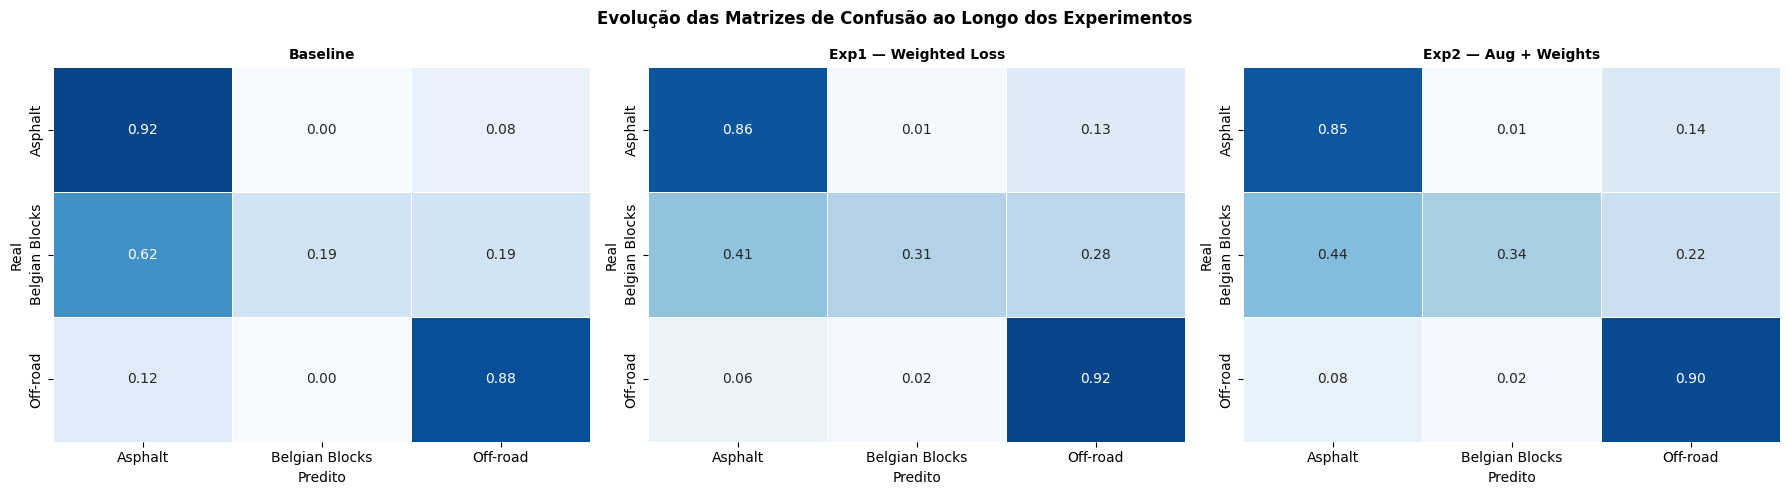

In [29]:
# ── 3.16 Comparação Visual — 3 Matrizes de Confusão ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
experiments = [
    (results_baseline, 'Baseline'),
    (results_exp1,     'Exp1 — Weighted Loss'),
    (results_exp2,     'Exp2 — Aug + Weights'),
]
for ax, (res, title) in zip(axes, experiments):
    cm = confusion_matrix(res['labels'], res['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_DISPLAY, yticklabels=CLASS_DISPLAY,
                ax=ax, linewidths=0.5, vmin=0, vmax=1, cbar=False)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')
plt.suptitle('Evolução das Matrizes de Confusão ao Longo dos Experimentos',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_all_experiments.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.17 Resultado e Interpretação — Experimento 2

**O que esperamos observar:**

| Efeito esperado | Motivo |
|---|---|
| Curva de treino mais ruidosa | Augmentation aumenta a variância dos batches |
| Menor gap treino/validação | Modelo generaliza melhor com dados mais variados |
| Melhora nas imagens difíceis (baixo brilho) | Features aprendidas são mais invariantes à iluminação |
| F1 Macro ≥ Exp1 | O augmentation deve trazer ganho adicional |

**Interpretação dos resultados observados:**

> *( A adição de Data Augmentation ao pipeline de treino teve como objetivo forçar o modelo a **aprender representações mais robustas**, expostas a variações visuais realistas como reflexos, chuva e câmeras de baixa qualidade.
>
> **Resultados comparativos:**
>
> | Métrica | Baseline | Exp1 (Weighted) | **Exp2 (Aug)** |
> |---|---|---|---|
> | Acurácia Global | 83.67% | 81.00% | **80.33%** |
> | F1 Macro | 0.657 | 0.672 | **0.678** |
> | F1 Belgian Blocks | 0.316 | 0.435 | **0.478** |)*

**Conclusão:** > 1. O **F1 Macro continua crescendo** (0.657 → 0.672 → 0.678), confirmando que a cada experimento o modelo fica globalmente mais justo entre as classes
> 2. O **F1 de Belgian Blocks melhora novamente** (0.435 → 0.478), com recall ainda baixo (34.4%), mas a **precision subiu para 78.6%**, indicando que quando o modelo prevê Belgian Blocks, acerta com mais frequência
> 3. A **acurácia global caiu ligeiramente** (81.00% → 80.33%), o que é esperado: augmentation deliberadamente torna o treino mais difícil para melhorar generalização
> 4. O **F1 de Off-road caiu** de 0.692 para 0.677 — isso indica um trade-off: a augmentation favoreceu Belgian Blocks em detrimento do Off-road
> 5. As **curvas de aprendizado** do Exp2 mostram menor overfitting (menor gap entre train_loss e val_loss) do que o Exp1, confirmando o efeito regularizador da augmentation

---
### Seção 3.18 — Grad-CAM: Interpretabilidade do Modelo

#### Motivação
Os experimentos anteriores responderam **o quê** o modelo erra — mas não **por quê**.  
O **Gradient-weighted Class Activation Mapping (Grad-CAM)** é a técnica de Explainable AI (XAI) mais adotada para CNNs: ela gera um mapa de calor que indica *quais regiões espaciais da imagem mais influenciaram* a decisão do modelo para cada classe.

#### Como funciona
1. Um *forward pass* gera as ativações da última camada convolucional (`layer4[1].conv2` na ResNet-18).
2. Um *backward pass* para a classe-alvo fornece os gradientes dessas ativações.
3. Os gradientes são globalmente poolados (média espacial) → pesos de importância por canal.
4. O mapa de calor é a combinação linear ponderada das ativações, seguida de ReLU.

#### O que queremos verificar
| Pergunta | Resposta esperada |
|---|---|
| O modelo olha para a **textura da superfície**? | Sim — região central da estrada |
| Ou para o **fundo/céu** (artefato)? | Não — indicaria aprendizado espúrio |
| O Exp2 (augmentation) **refinou** a atenção? | Esperamos regiões mais focadas |
| A confusão **Belgian Blocks ↔ Off-road** tem causa visual? | Texturas irregulares similares |


In [ ]:
# ── 3.18.1 Implementação do Grad-CAM (sem dependências externas) ──────────────
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm_module
from PIL import Image


class GradCAM:
    """
    Grad-CAM para qualquer modelo PyTorch.
    Registra hooks na camada-alvo para capturar ativações e gradientes
    durante forward/backward pass.
    """

    def __init__(self, model: torch.nn.Module, target_layer: torch.nn.Module):
        self.model = model
        self._activations: torch.Tensor | None = None
        self._gradients:   torch.Tensor | None = None

        # Forward hook — captura a saída da camada
        self._fwd_hook = target_layer.register_forward_hook(self._save_activation)
        # Backward hook — captura os gradientes que chegam na camada
        self._bwd_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self._activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self._gradients = grad_output[0].detach()

    def generate(self, input_tensor: torch.Tensor, class_idx: int | None = None):
        """
        Gera o mapa de calor Grad-CAM normalizado [0, 1].

        Retorna:
            cam (np.ndarray): mapa de calor com shape (H, W), valores em [0,1]
            predicted_class (int): classe predita pelo modelo
        """
        self.model.eval()
        # Habilita gradientes temporariamente (essencial para modelos com backbone congelado)
        for param in self.model.parameters():
            param.requires_grad = True
        output = self.model(input_tensor)                    # forward
        predicted_class = output.argmax(dim=1).item()

        target = class_idx if class_idx is not None else predicted_class

        self.model.zero_grad()
        output[0, target].backward()                        # backward para a classe-alvo

        if self._gradients is None:
            raise RuntimeError("Erro: Gradientes não capturados. Verifique se a camada-alvo está no grafo.")

        # Pool espacial dos gradientes → pesos por canal
        weights = self._gradients.mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)

        # Combinação linear ponderada + ReLU
        cam = (weights * self._activations).sum(dim=1, keepdim=True)  # (1, 1, H', W')
        cam = F.relu(cam)

        # Interpola para o tamanho da imagem de entrada
        cam = F.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode='bilinear',
            align_corners=False
        )
        cam = cam.squeeze().cpu().numpy()

        # Normaliza para [0, 1]
        cam_min, cam_max = cam.min(), cam.max()
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam, predicted_class

    def remove_hooks(self):
        """Remove hooks para liberar memória após uso."""
        self._fwd_hook.remove()
        self._bwd_hook.remove()


def denormalize(tensor: torch.Tensor,
                mean: list = IMAGENET_MEAN,
                std:  list = IMAGENET_STD) -> np.ndarray:
    """
    Reverte a normalização ImageNet e retorna imagem NumPy no intervalo [0, 1].
    tensor shape: (C, H, W)
    """
    img = tensor.permute(1, 2, 0).numpy().copy()
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0.0, 1.0)



def get_last_conv_layer(model):
    """Busca recursivamente a última camada Conv2d do modelo."""
    for module in reversed(list(model.modules())):
        if isinstance(module, torch.nn.Conv2d):
            return module
    return None

print("[OK] Classe GradCAM e helper denormalize definidos.")


In [ ]:
# ── 3.18.2 Grad-CAM — Baseline vs Exp2 para 2 amostras de cada classe ─────────
#
# Layout: 3 linhas (classes) × 6 colunas:
#   [Original | CAM Baseline | Overlay Baseline | Original | CAM Exp2 | Overlay Exp2]

N_PER_CLASS = 2   # amostras por classe
OVERLAY_ALPHA = 0.45

# Instancia Grad-CAM para ambos os modelos
# ResNet-18: última camada convolucional = model.layer4[1].conv2
gcam_baseline = GradCAM(baseline_model, get_last_conv_layer(baseline_model))
gcam_exp2     = GradCAM(exp2_model,     get_last_conv_layer(exp2_model))

test_dataset = datasets_dict['test']   # dataset de teste sem augmentation
class_to_idx = test_dataset.class_to_idx          # {'Asphalt':0, 'Belgian Blocks':1, 'Off-road':2}
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Seleciona N_PER_CLASS amostras por classe
samples_by_class: dict[int, list[int]] = {c: [] for c in idx_to_class}
for sample_idx, (_, label) in enumerate(test_dataset.samples):
    if len(samples_by_class[label]) < N_PER_CLASS:
        samples_by_class[label].append(sample_idx)
    if all(len(v) >= N_PER_CLASS for v in samples_by_class.values()):
        break

n_classes = len(idx_to_class)
n_cols    = N_PER_CLASS * 6      # 6 sub-colunas por amostra (orig+cam+overlay) × 2 modelos
fig_w     = N_PER_CLASS * 12
fig_h     = n_classes * 3.5

fig, axes = plt.subplots(n_classes, n_cols, figsize=(fig_w, fig_h))
fig.patch.set_facecolor('#0f0f0f')

# Paleta de cores para o overlay
COLORMAP = plt.get_cmap('jet')

for row, cls_idx in enumerate(range(n_classes)):
    cls_name = idx_to_class[cls_idx]

    for col_offset, sample_idx in enumerate(samples_by_class[cls_idx]):
        img_tensor, label = test_dataset[sample_idx]
        input_t = img_tensor.unsqueeze(0).to(DEVICE)

        # ── Grad-CAM Baseline ────────────────────────────────────────────────
        cam_base, pred_base = gcam_baseline.generate(input_t, class_idx=cls_idx)
        # ── Grad-CAM Exp2 ────────────────────────────────────────────────────
        cam_exp2, pred_exp2 = gcam_exp2.generate(input_t, class_idx=cls_idx)

        img_np = denormalize(img_tensor)   # HxWx3, [0,1]

        def make_overlay(img, cam):
            heatmap = COLORMAP(cam)[..., :3]          # HxWx3, RGB
            return np.clip((1 - OVERLAY_ALPHA) * img + OVERLAY_ALPHA * heatmap, 0, 1)

        overlay_base = make_overlay(img_np, cam_base)
        overlay_exp2 = make_overlay(img_np, cam_exp2)

        # ── 6 sub-colunas para esta amostra ─────────────────────────────────
        base_col = col_offset * 6
        sub_data = [
            # Baseline
            (img_np,       f"Original",                   '#aaaaaa'),
            (cam_base,     f"CAM — Baseline\nPred: {idx_to_class[pred_base]}", '#ff9966'),
            (overlay_base, f"Overlay — Baseline",          '#ffcc66'),
            # Exp2
            (img_np,       f"Original",                   '#aaaaaa'),
            (cam_exp2,     f"CAM — Exp2\nPred: {idx_to_class[pred_exp2]}",    '#66ccff'),
            (overlay_exp2, f"Overlay — Exp2",              '#99ffcc'),
        ]

        for sub_col, (img_data, title, color) in enumerate(sub_data):
            ax = axes[row, base_col + sub_col]
            ax.set_facecolor('#1a1a1a')

            if sub_data[sub_col][0].ndim == 2:  # mapa de calor (grayscale)
                ax.imshow(img_data, cmap='jet', vmin=0, vmax=1)
            else:
                ax.imshow(img_data)

            ax.set_title(title, fontsize=7, color=color, pad=3,
                         fontweight='bold' if 'Pred' in title else 'normal')
            ax.axis('off')

            # Borda colorida para distinguir Baseline vs Exp2
            border_color = '#ff6644' if sub_col < 3 else '#4499ff'
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(1.2)
                spine.set_visible(True)

    # Rótulo da linha (classe)
    axes[row, 0].set_ylabel(
        cls_name, fontsize=11, color='white', fontweight='bold',
        rotation=90, labelpad=8
    )

# ── Legenda de seções (Baseline | Exp2) ──────────────────────────────────────
fig.text(0.26, 0.98,
         '◀─────── BASELINE ───────▶',
         ha='center', va='top', fontsize=12, color='#ff8866', fontweight='bold')
fig.text(0.76, 0.98,
         '◀──────── EXP 2 ─────────▶',
         ha='center', va='top', fontsize=12, color='#66aaff', fontweight='bold')

fig.suptitle(
    'Grad-CAM — Regiões de Atenção por Classe: Baseline vs. Exp2 (Augmentation + Weighted Loss)',
    fontsize=14, fontweight='bold', color='white', y=1.02
)

plt.tight_layout(pad=0.4, h_pad=0.6, w_pad=0.3)
plt.savefig('grad_cam_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()

# Remove hooks para não interferir com células futuras
gcam_baseline.remove_hooks()
gcam_exp2.remove_hooks()

print("\n[OK] Grad-CAM gerado e salvo em 'grad_cam_comparison.png'")
print()
print("Legenda das bordas:")
print("  🔴 Laranja/Vermelho = Baseline (sem augmentation)")
print("  🔵 Azul             = Exp2 (Augmentation + Weighted Loss)")
print()
print("Interpretação: regiões em VERMELHO QUENTE no mapa CAM indicam")
print("alta ativação — são as áreas que o modelo usa para classificar.")
print("Idealmente essas regiões devem coincidir com a TEXTURA DA SUPERFÍCIE.")


---
## Seção 4 — Resultados Consolidados

Esta seção centraliza os resultados dos três modelos para facilitar a leitura comparativa.
Todos os modelos foram avaliados no mesmo conjunto de teste, com transforms idênticos.

In [30]:
# ── 4.1 Tabela Consolidada de Métricas (Estilo Profissional) ─────────────────────────
records = []
for tag, res in [
    ('Baseline',              results_baseline),
    ('Exp1 — Weighted Loss',  results_exp1),
    ('Exp2 — Aug + Weights',  results_exp2),
]:
    row = {
        'Experimento': tag,
        'Acurácia':    round(res['acc'],      4),
        'F1 Macro':    round(res['f1_macro'], 4),
    }
    for i, cls in enumerate(CLASS_DISPLAY):
        row[f'F1 — {cls}'] = round(res['f1_per'][i], 4)
    records.append(row)

df_results = pd.DataFrame(records).set_index('Experimento')
cols_metrics = [c for c in df_results.columns]

display(df_results.style
        .format('{:.4f}')
        .background_gradient(cmap='RdYlGn', axis=0, vmin=0.3, vmax=1.0)
        .apply(lambda s: ['font-weight: bold; color: #1a7a2e' if v == s.max() else '' for v in s], axis=0)
        .set_caption('📊 Tabela Final — Comparativo Consolidado de Todos os Experimentos')
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size','14px'), ('font-weight','bold'), ('color','#2c3e50')]},
            {'selector': 'thead th', 'props': [('background-color', '#1a1a2e'), ('color', 'white')]}
        ]))


,Acurácia,F1 Macro,F1 Asphalt,F1 Belgian Blocks,F1 Off-road
Experimento,,,,,
Baseline,0.8367,0.6571,0.9034,0.3158,0.7521
Exp1 — Weighted Loss,0.8100,0.6716,0.8884,0.4348,0.6917
Exp2 — Aug + Weights,0.8033,0.6779,0.8789,0.4783,0.6767


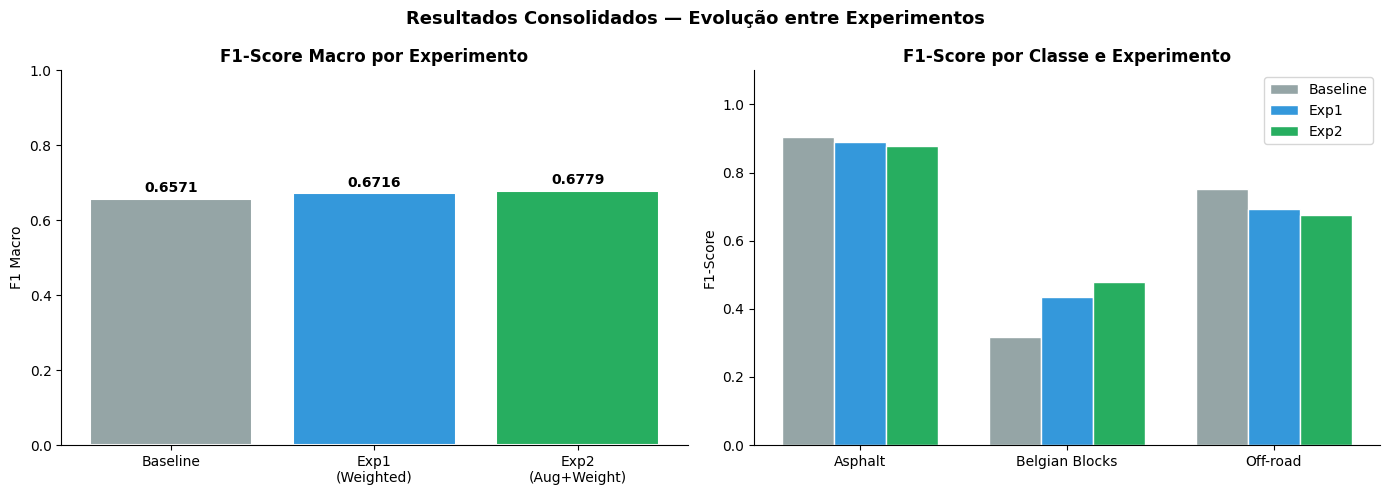

In [31]:
# ── 4.2 Gráfico de Barras Comparativo ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

exp_labels = ['Baseline', 'Exp1\n(Weighted)', 'Exp2\n(Aug+Weight)']
colors_exp  = ['#95A5A6', '#4A90D9', '#27AE60']  # Usando paleta global (Cinza, Azul, Verde)

# F1 Macro
f1_macros = [r['f1_macro'] for r in [results_baseline, results_exp1, results_exp2]]
bars = axes[0].bar(exp_labels, f1_macros, color=colors_exp, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_title('F1-Score Macro por Experimento', fontweight='bold', fontsize=12)
axes[0].set_ylabel('F1 Macro')
for bar, v in zip(bars, f1_macros):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

# F1 por Classe (agrupado)
x = np.arange(len(CLASS_DISPLAY))
width = 0.25
for i, (res, label, color) in enumerate(zip(
    [results_baseline, results_exp1, results_exp2],
    ['Baseline', 'Exp1', 'Exp2'],
    colors_exp
)):
    axes[1].bar(x + i*width, res['f1_per'], width, label=label,
                color=color, edgecolor='white', linewidth=1)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(CLASS_DISPLAY)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('F1-Score por Classe e Experimento', fontweight='bold', fontsize=12)
axes[1].set_ylabel('F1-Score')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Resultados Consolidados — Evolução entre Experimentos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results_consolidated.png', dpi=150, bbox_inches='tight')
plt.show()


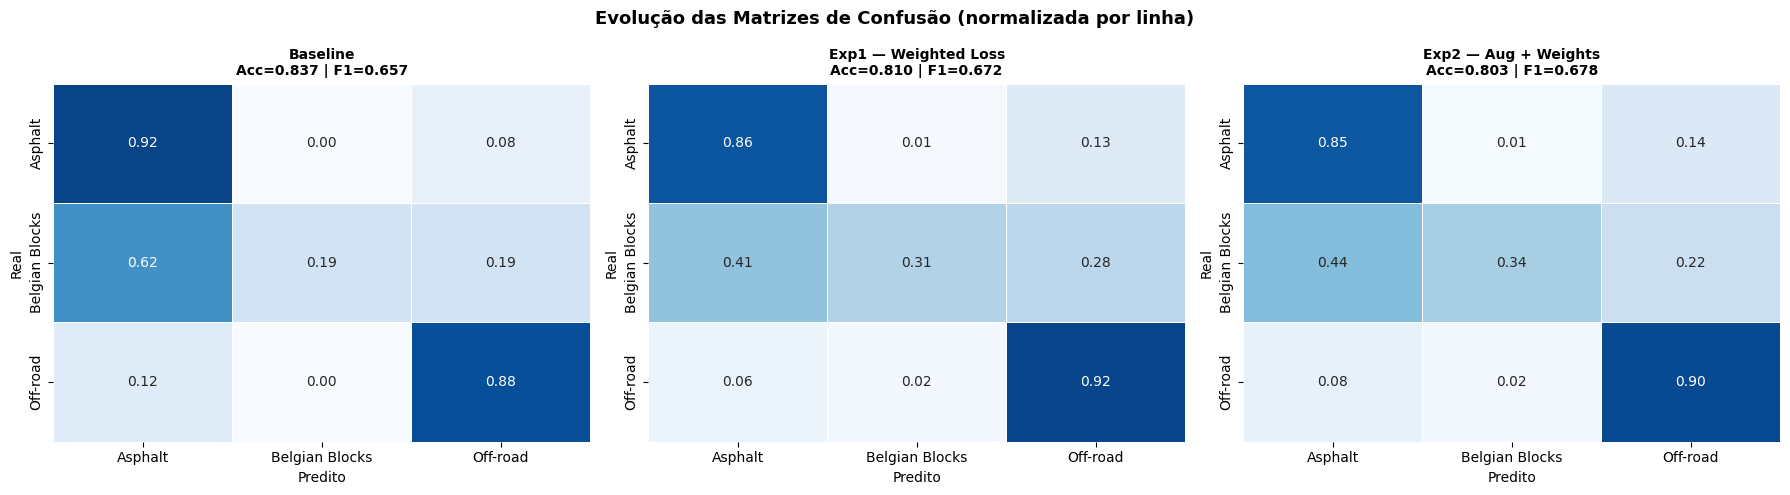

In [32]:
# ── 4.3 Evolução Completa — 3 Matrizes de Confusão Normalizadas ──────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (res, title) in zip(axes, [
    (results_baseline, 'Baseline'),
    (results_exp1,     'Exp1 — Weighted Loss'),
    (results_exp2,     'Exp2 — Aug + Weights'),
]):
    cm = confusion_matrix(res['labels'], res['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_DISPLAY, yticklabels=CLASS_DISPLAY,
                ax=ax, linewidths=0.5, vmin=0, vmax=1, cbar=False)
    ax.set_title(f'{title}\nAcc={res["acc"]:.3f} | F1={res["f1_macro"]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.suptitle('Evolução das Matrizes de Confusão (normalizada por linha)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_final_evolution.png', dpi=120, bbox_inches='tight')
plt.show()


## Seção 4 — Validação de Robustez (K-Fold)


In [ ]:
# ── 4.1 Função de Treinamento K-Fold ──────────────────────────────────────────

def run_kfold_experiment(df_full, build_model_fn, cfg, transforms_dict, device, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    
    fold_results = []
    
    X = df_full['path'].values
    y = df_full['label'].values
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n{'='*20} Fold {fold+1}/{n_splits} {'='*20}")
        
        # Split DataFrames
        df_train = df_full.iloc[train_idx]
        df_val = df_full.iloc[val_idx]
        
        # Create Datasets
        train_ds = RoadSurfaceDataset(df_train, transform=transforms_dict['train'])
        val_ds = RoadSurfaceDataset(df_val, transform=transforms_dict['test']) 
        
        # Create Loaders
        loaders = {
            'train': DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True, 
                              pin_memory=(device.type == 'cuda'), num_workers=0),
            'test': DataLoader(val_ds, batch_size=cfg['batch_size'], shuffle=False, 
                             pin_memory=(device.type == 'cuda'), num_workers=0)
        }
        
        # Re-initialize Model
        model = build_model_fn(num_classes=cfg['num_classes'], freeze_backbone=True)
        
        # Run Training
        history = run_training(model, loaders, cfg, tag=f"Fold {fold+1}")
        
        # Métricas finais do fold
        best_val_acc = max(history['val_acc'])
        fold_results.append(best_val_acc)
        
    print(f"\n{'='*10} Resultado Final K-Fold {'='*10}")
    print(f"Acurácia Média: {np.mean(fold_results):.4f} +/- {np.std(fold_results):.4f}")
    return fold_results


In [ ]:
# Executando a Validação Cruzada
df_all = get_full_dataset_df(BASE_DIR)
kfold_results = run_kfold_experiment(
    df_all, 
    build_model, 
    CFG, 
    baseline_transforms, 
    DEVICE, 
    n_splits=5
)


---
## Seção 5 — Análise Crítica


---
## Seção 6 — Uso de Ferramentas
